In [1]:
import os
import sys
sys.path.insert(0, "../..")

import ast
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

from src.constants import C2A_PALETTE, DATA_PATH
plt.rcParams['figure.dpi'] = 300

## 1 - Loading and Preprocessing Grounder Results DF

In [2]:
import math
import json

def parse_annotation(df):
    parsed = df['annotation'].apply(ast.literal_eval)
    df['img_filename'] = parsed.apply(lambda x: x['img_filename'])
    df['bbox']         = parsed.apply(lambda x: x['bbox'])        # [x1, y1, x2, y2] absolute pixels
    df['img_size']     = parsed.apply(lambda x: x['img_size'])    # [W, H]
    df['ui_type']      = parsed.apply(lambda x: x['ui_type'])
    df['application']  = parsed.apply(lambda x: x['application'])
    df['platform']     = parsed.apply(lambda x: x['platform'])
    return df

def parse_uizoom_output(df):
    parsed = df['raw_output'].apply(ast.literal_eval)
    df['cropped_bbox']          = parsed.apply(lambda x: x['ui_zoomer_output']['bbox'])
    df['use_voted_point']       = parsed.apply(lambda x: x['ui_zoomer_output']['use_voted_point'])
    df['voted_point_x']         = parsed.apply(lambda x: x['ui_zoomer_output']['voted_point'][0])
    df['voted_point_y']         = parsed.apply(lambda x: x['ui_zoomer_output']['voted_point'][1])
    df['spatial_confidence']    = parsed.apply(lambda x: x['ui_zoomer_output']['spatial_confidence'])
    df['confidence']            = parsed.apply(lambda x: x['ui_zoomer_output']['confidence'])
    df['tokens_confidences']    = parsed.apply(lambda x: x['ui_zoomer_output']['tokens_confidences'])
    return df

def voted_point_in_bbox(row):
    x1, y1, x2, y2 = row['bbox']
    px, py = row['voted_point_x'], row['voted_point_y']
    return x1 <= px <= x2 and y1 <= py <= y2 

def ann_bbox_in_cropped_bbox(row):
    try:
        x1, y1, x2, y2 = row['bbox']
        xc1, yc1, xc2, yc2 = row['cropped_bbox']
        return x1 >= xc1 and y1 >= yc1 and x2 <= xc2 and y2 <= yc2
    except:
        return np.nan
    
def point_in_bbox(row):
    W, H = row['img_size']                                                                                                                                    
    px = row['coord_x'] * W
    py = row['coord_y'] * H                                                                                                                                   
    x1, y1, x2, y2 = row['bbox']
    return x1 <= px <= x2 and y1 <= py <= y2    

def distance_to_bbox_edge(row):
    "This metric returns 0 if the point is inside the box. If the point is outside, it calculates the shortest Euclidean distance to the nearest edge or corner."
    W, H = row['img_size']
    px = row['coord_x'] * W
    py = row['coord_y'] * H
    x1, y1, x2, y2 = row['bbox']
    # Distance to the horizontal and vertical edges (0 if inside the bounds)
    dx = max(0, x1 - px, px - x2)
    # dy logic uses y1-py and py-y2 assuming y1 < y2 (top-left to bottom-right)
    dy = max(0, y1 - py, py - y2) 
    return math.hypot(dx, dy)

def distance_to_bbox_center(row):
    W, H = row['img_size']
    px = row['coord_x'] * W
    py = row['coord_y'] * H
    x1, y1, x2, y2 = row['bbox']

    # Calculate centroid of the bbox
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    return math.hypot(px - cx, py - cy)

def normalized_distance_to_center(row):
    "We divide the absolute distance in $x$ and $y$ by the width ($w$) and height ($h$) of the bounding box, respectively."
    W, H = row['img_size']
    px = row['coord_x'] * W
    py = row['coord_y'] * H
    x1, y1, x2, y2 = row['bbox']

    # Bbox dimensions
    box_w = x2 - x1
    box_h = y2 - y1
    
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    # Normalize distances by box dimensions
    norm_dx = (px - cx) / box_w
    norm_dy = (py - cy) / box_h

    # Return a scale-invariant distance
    return math.hypot(norm_dx, norm_dy)

In [3]:
results = pd.read_csv("grounder.csv", index_col=0)

In [4]:
results['coord_x'].isna().sum()

140

In [5]:
results = results[~results['coord_x'].isna()]

results = parse_annotation(results)
results = parse_uizoom_output(results)

In [6]:
results['use_voted_point'].mean()

0.42678695350451074

In [7]:
# results         = results[~results['coord_x'].isna()]
results['hit']                      = results.apply(point_in_bbox, axis=1)
results['dist_to_edge']             = results.apply(distance_to_bbox_edge, axis=1)
results['dist_to_center']           = results.apply(distance_to_bbox_center, axis=1)
results['dist_to_center_norm']      = results.apply(normalized_distance_to_center, axis=1)
results['voted_point_hit']          = results.apply(voted_point_in_bbox, axis=1)
results['cropped_box_hit']          = results.apply(ann_bbox_in_cropped_bbox, axis=1)

results['app/platform'] = results.apply(lambda r: r['application'] + f" ({r['platform']})", axis=1)
results['img_area']     = results.apply(lambda r: r['img_size'][0]*r['img_size'][1], axis=1)
results['bbox_area']    = results.apply(lambda r: (r['bbox'][2] - r['bbox'][0])*(r['bbox'][3] - r['bbox'][1]), axis=1)


In [8]:
results = results[~results['coord_x'].isna()]

In [9]:
results['hit'].value_counts()

hit
False    1082
True      359
Name: count, dtype: int64

In [10]:
results['hit'].value_counts(normalize=True)

hit
False    0.750867
True     0.249133
Name: proportion, dtype: float64

In [11]:
results['voted_point_hit'].value_counts(normalize=True)

voted_point_hit
False    0.798057
True     0.201943
Name: proportion, dtype: float64

In [12]:
results['cropped_box_hit'].value_counts(dropna=True, normalize=True)

cropped_box_hit
True     0.748184
False    0.251816
Name: proportion, dtype: float64

## Visualization

### Utils/Plot/Vis Functions

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle, Circle

DATASET_ROOT = DATA_PATH / "raw" / "screenspot_pro" / "images"

def visualize_row(row, radius=4, bbox_line_width=3, circle_line_width=1.5, fontsize=8, save_file_path = None):
    W, H = row["img_size"]
    px, py = row["coord_x"] * W, row["coord_y"] * H
    bx1, by1, bx2, by2 = row["bbox"]
    img = Image.open(f"{DATASET_ROOT}/{row['img_filename']}")

    fig, ax = plt.subplots(figsize=(14, 14 * H / W))
    ax.imshow(img)
    ax.axis("off")

    # bbox: fill + outline
    ax.add_patch(Rectangle(
        (bx1, by1), bx2 - bx1, by2 - by1,
        facecolor=(*[int(C2A_PALETTE["tertiary"][i:i+2], 16)/255 for i in (1, 3, 5)], 0.2),
        edgecolor=C2A_PALETTE["tertiary"], linewidth=bbox_line_width,
    ))

    # click: big translucent circle + outline
    ax.plot(px, py, "r+", markersize=radius, markeredgewidth=circle_line_width)
    ax.plot(px, py, "o", markersize=radius, markeredgewidth=circle_line_width, markerfacecolor="none", markeredgecolor="red")

    # task: yellow box in top-left with arrow to bbox
    xmid, ymid = (bx1 + bx2)/2, (by1 + by2)/2
    xtext = xmid + 100 if xmid + 100 < W else xmid - 100 
    ytext = ymid - 100 if ymid - 100 > H else ymid + 100 
    ax.annotate(
        f"{row['task']}",
        xy=(xmid, ymid),
        xytext=(xtext, ytext),
        arrowprops=dict(arrowstyle="->", color=C2A_PALETTE["tertiary"]),
        bbox=dict(boxstyle="round,pad=0.3", facecolor=C2A_PALETTE["tertiary"], alpha=0.7),
        fontsize=fontsize,
    )


    plt.tight_layout()
    if save_file_path:
        plt.savefig(f"./results/samples/{save_file_path}")
    else:
        plt.show()


### Visualize ScreenSpot-Pro dataset

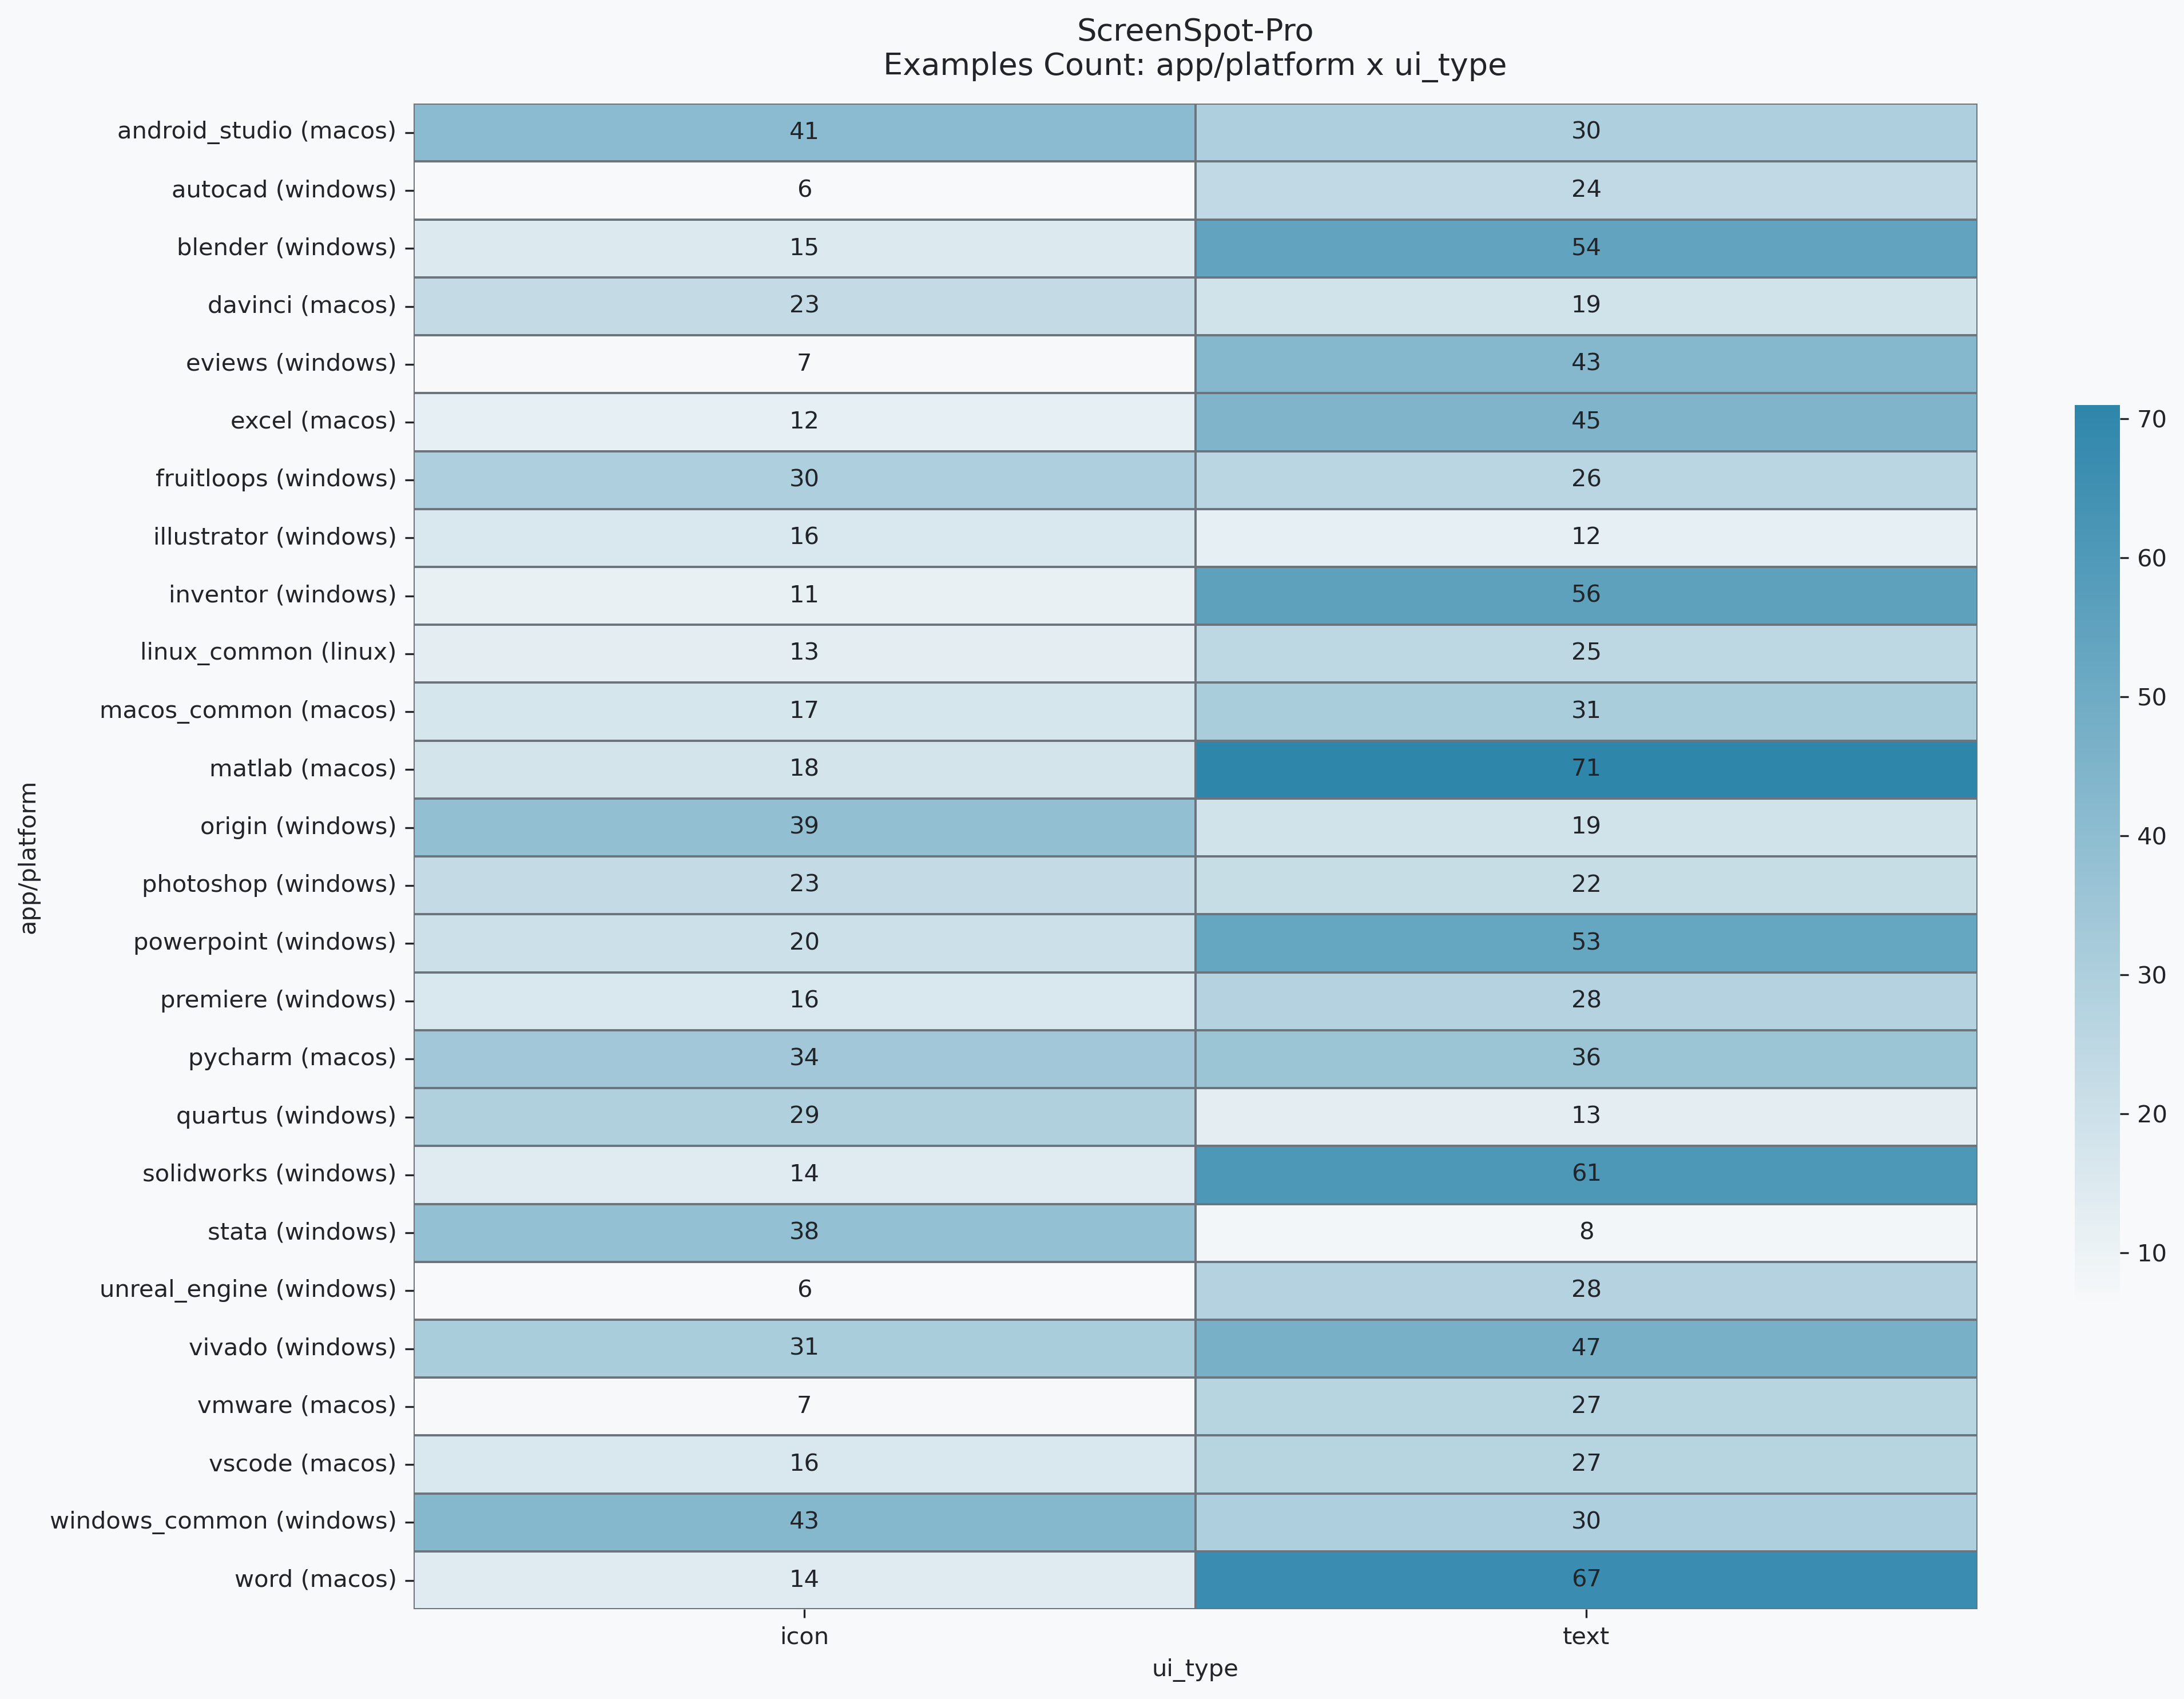

In [14]:

def plot_screenspot_pro_dist(df, figsize=(14, 10)):
    pivot = df.groupby(['app/platform', 'ui_type']).size().unstack(fill_value=0)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "c2a", [C2A_PALETTE["bg"], C2A_PALETTE["primary"]]
    )

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    sns.heatmap(
        pivot,
        annot=True,
        fmt="d",
        cmap=cmap,
        linewidths=0.5,
        linecolor=C2A_PALETTE["neutral"],
        ax=ax,
        annot_kws={"color": C2A_PALETTE["text"], "size": 10},
        cbar_kws={"shrink": 0.6},
    )

    ax.set_title("ScreenSpot-Pro\nExamples Count: app/platform x ui_type", color=C2A_PALETTE["text"], fontsize=13, pad=12)
    ax.set_xlabel("ui_type", color=C2A_PALETTE["text"])
    ax.set_ylabel("app/platform", color=C2A_PALETTE["text"])
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.xaxis.label.set_color(C2A_PALETTE["text"])
    ax.yaxis.label.set_color(C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), color=C2A_PALETTE["text"])
    plt.setp(ax.get_yticklabels(), color=C2A_PALETTE["text"], rotation=0)
    ax.collections[0].colorbar.ax.tick_params(colors=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/screenspot-pro-examples-counts.png")
    plt.show()

plot_screenspot_pro_dist(results)

### Init Visualization of Failed Examples

In [11]:
# from tqdm.auto import tqdm
# for row in tqdm(results[~results['hit']].sample(frac=1).iterrows()):
#     visualize_row(row[1], radius=8, save_file_path=f"failed_{row[0]}.png")

In [15]:
results['hit'].mean()

0.24913254684247052

In [16]:
print((results.groupby('app/platform')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| app/platform             |      hit |
|:-------------------------|---------:|
| eviews (windows)         | 72       |
| word (macos)             | 46.9136  |
| matlab (macos)           | 41.573   |
| vivado (windows)         | 35.8974  |
| vmware (macos)           | 35.2941  |
| powerpoint (windows)     | 34.2466  |
| vscode (macos)           | 32.5581  |
| premiere (windows)       | 31.8182  |
| linux_common (linux)     | 31.5789  |
| unreal_engine (windows)  | 29.4118  |
| blender (windows)        | 27.5362  |
| macos_common (macos)     | 22.9167  |
| fruitloops (windows)     | 19.6429  |
| inventor (windows)       | 19.403   |
| excel (macos)            | 19.2982  |
| quartus (windows)        | 19.0476  |
| photoshop (windows)      | 17.7778  |
| pycharm (macos)          | 17.1429  |
| windows_common (windows) | 16.4384  |
| origin (windows)         | 12.069   |
| stata (windows)          | 10.8696  |
| solidworks (windows)     |  9.33333 |
| davinci (macos)          |  7.14286 |


In [17]:
print((results.groupby('ui_type')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| ui_type   |      hit |
|:----------|---------:|
| text      | 35.8093  |
| icon      |  6.67904 |


In [18]:
print((results.groupby('platform')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| platform   |     hit |
|:-----------|--------:|
| linux      | 31.5789 |
| macos      | 26.5421 |
| windows    | 23.6175 |


In [19]:
print(results[~results['hit']]['dist_to_edge'].describe().to_markdown())

|       |   dist_to_edge |
|:------|---------------:|
| count | 1082           |
| mean  |  633.568       |
| std   |  772.01        |
| min   |    1.13687e-13 |
| 25%   |   63.2495      |
| 50%   |  244.175       |
| 75%   |  992.266       |
| max   | 3916.19        |


In [20]:
print(results[~results['hit']]['dist_to_center'].describe().to_markdown())

|       |   dist_to_center |
|:------|-----------------:|
| count |        1082      |
| mean  |         665.453  |
| std   |         771.501  |
| min   |          10.0791 |
| 25%   |          91.1415 |
| 50%   |         289.753  |
| 75%   |        1036.94   |
| max   |        3940.32   |


In [21]:
print(results[~results['hit']]['dist_to_center_norm'].describe().to_markdown())

|       |   dist_to_center_norm |
|:------|----------------------:|
| count |           1082        |
| mean  |             21.409    |
| std   |             28.7399   |
| min   |              0.500087 |
| 25%   |              2.21636  |
| 50%   |              8.32035  |
| 75%   |             30.1747   |
| max   |            214.404    |


In [22]:
results.groupby('ui_type')['hit'].mean().sort_values()[::-1]

ui_type
text    0.358093
icon    0.066790
Name: hit, dtype: float64

In [23]:
results.groupby('platform')['hit'].mean().sort_values()[::-1]

platform
linux      0.315789
macos      0.265421
windows    0.236175
Name: hit, dtype: float64

In [24]:
# results.apply(lambda r: print(r))

In [25]:
results.groupby('app/platform')['hit'].mean().sort_values()[::-1]

app/platform
eviews (windows)            0.720000
word (macos)                0.469136
matlab (macos)              0.415730
vivado (windows)            0.358974
vmware (macos)              0.352941
powerpoint (windows)        0.342466
vscode (macos)              0.325581
premiere (windows)          0.318182
linux_common (linux)        0.315789
unreal_engine (windows)     0.294118
blender (windows)           0.275362
macos_common (macos)        0.229167
fruitloops (windows)        0.196429
inventor (windows)          0.194030
excel (macos)               0.192982
quartus (windows)           0.190476
photoshop (windows)         0.177778
pycharm (macos)             0.171429
windows_common (windows)    0.164384
origin (windows)            0.120690
stata (windows)             0.108696
solidworks (windows)        0.093333
davinci (macos)             0.071429
android_studio (macos)      0.056338
illustrator (windows)       0.035714
autocad (windows)           0.033333
Name: hit, dtype: float64

In [26]:
results.groupby('img_area')['hit'].mean().sort_values()[::-1]

img_area
3110400     0.427083
4259840     0.388889
5184000     0.342466
3686400     0.331959
7464960     0.315789
4096000     0.285714
7720704     0.246269
7372800     0.181818
14745600    0.140625
4147200     0.122093
8294400     0.117886
2073600     0.105263
20358144    0.000000
5595040     0.000000
Name: hit, dtype: float64

### Visualization of Hit Patterns

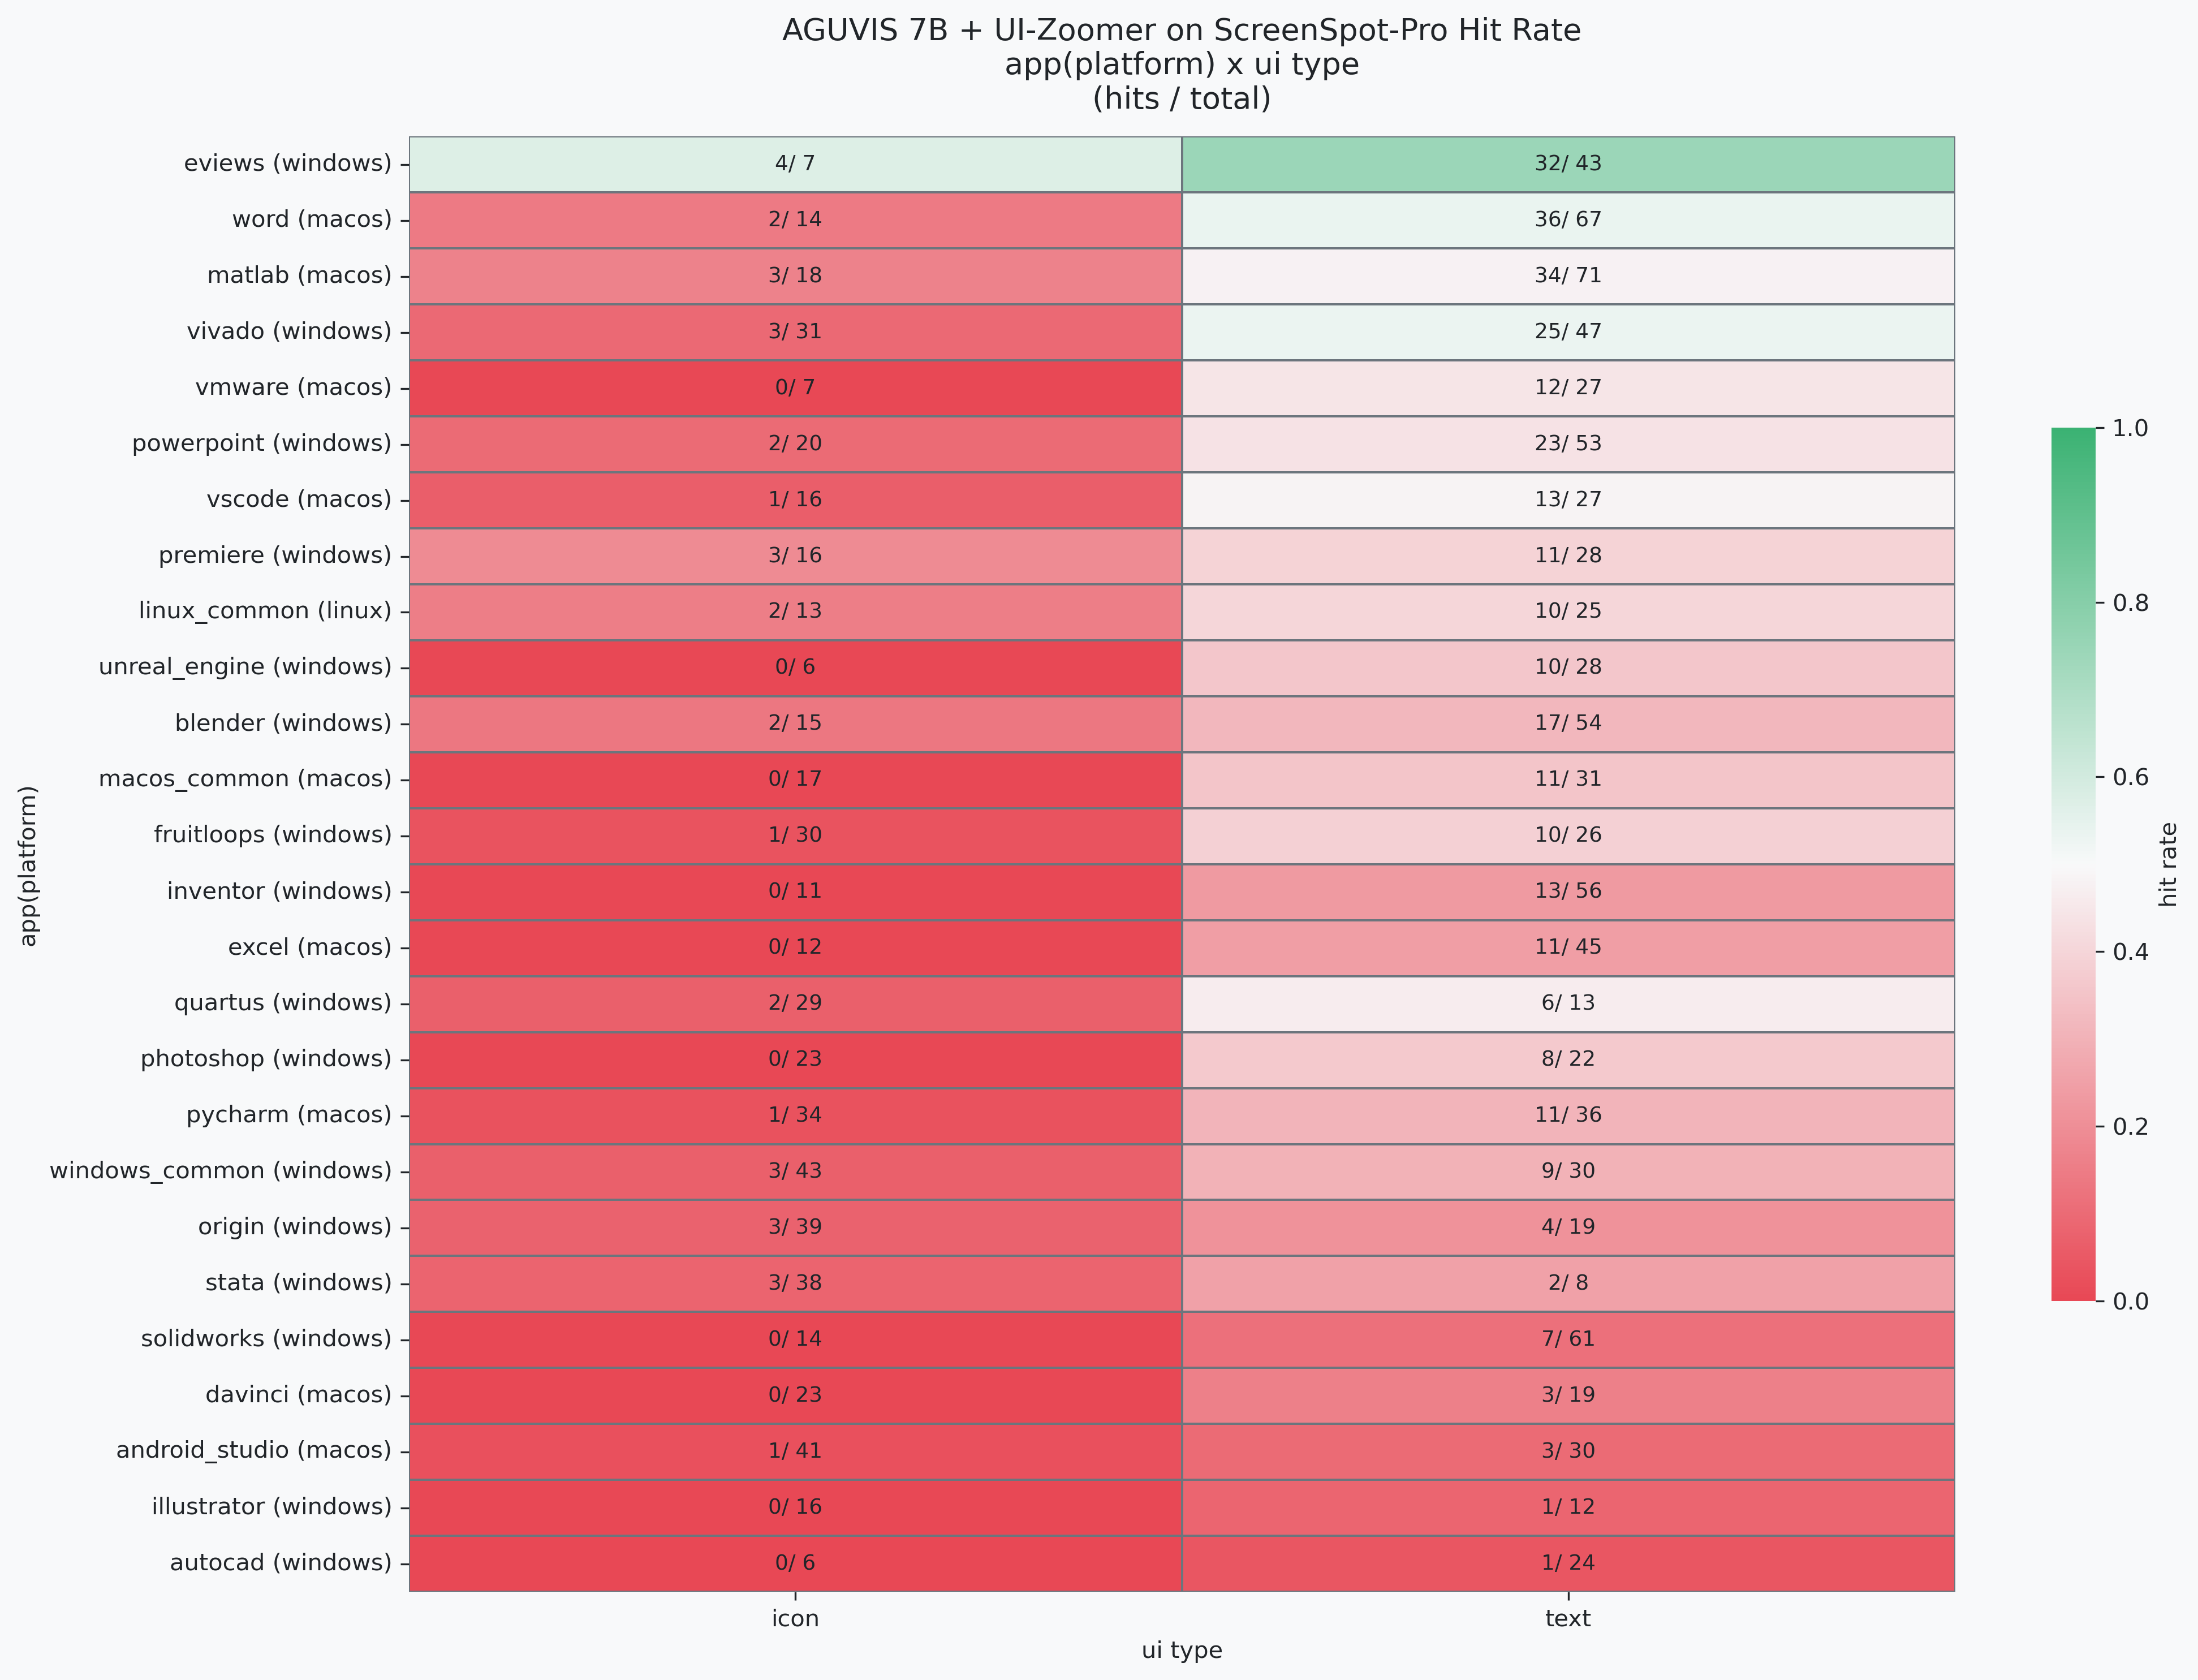

In [27]:

def plot_hit_heatmap(df, figsize=(14, 10)):
    order = df.groupby('app/platform')['hit'].mean().sort_values(ascending=False).index

    grp    = df.groupby(['app/platform', 'ui_type'])['hit']
    hits   = grp.sum().unstack(fill_value=0)
    totals = grp.count().unstack(fill_value=0)
    rates  = (hits / totals.replace(0, float('nan'))).fillna(0)

    # 2. Reorder the rows of all dataframes based on the calculated order
    hits   = hits.reindex(order)
    totals = totals.reindex(order)
    rates  = rates.reindex(order)


    # annotation: "hits/total"
    annot = hits.astype(int).astype(str) + "/ " + totals.astype(int).astype(str)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "c2a_hit", [C2A_PALETTE["warning"], C2A_PALETTE["bg"], C2A_PALETTE["success"]]
    )

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    sns.heatmap(
        rates,
        annot=annot,
        fmt="",
        cmap=cmap,
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor=C2A_PALETTE["neutral"],
        ax=ax,
        annot_kws={"color": C2A_PALETTE["text"], "size": 9},
        cbar_kws={"shrink": 0.6, "label": "hit rate"},
    )

    ax.set_title("AGUVIS 7B + UI-Zoomer on ScreenSpot-Pro Hit Rate\napp(platform) x ui type\n(hits / total)", color=C2A_PALETTE["text"], fontsize=13, pad=12)
    ax.set_xlabel("ui type", color=C2A_PALETTE["text"])
    ax.set_ylabel("app(platform)", color=C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), color=C2A_PALETTE["text"])
    plt.setp(ax.get_yticklabels(), color=C2A_PALETTE["text"], rotation=0)
    ax.tick_params(colors=C2A_PALETTE["text"])
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors=C2A_PALETTE["text"])
    cbar.ax.yaxis.label.set_color(C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/aguvis-screenspot-pro-examples-hit-rate-counts.png")
    plt.show()

plot_hit_heatmap(results)

In [25]:
# results[(results['application'] == 'word') & (results['ui_type'] == 'icon') & (results['hit'] == False)]

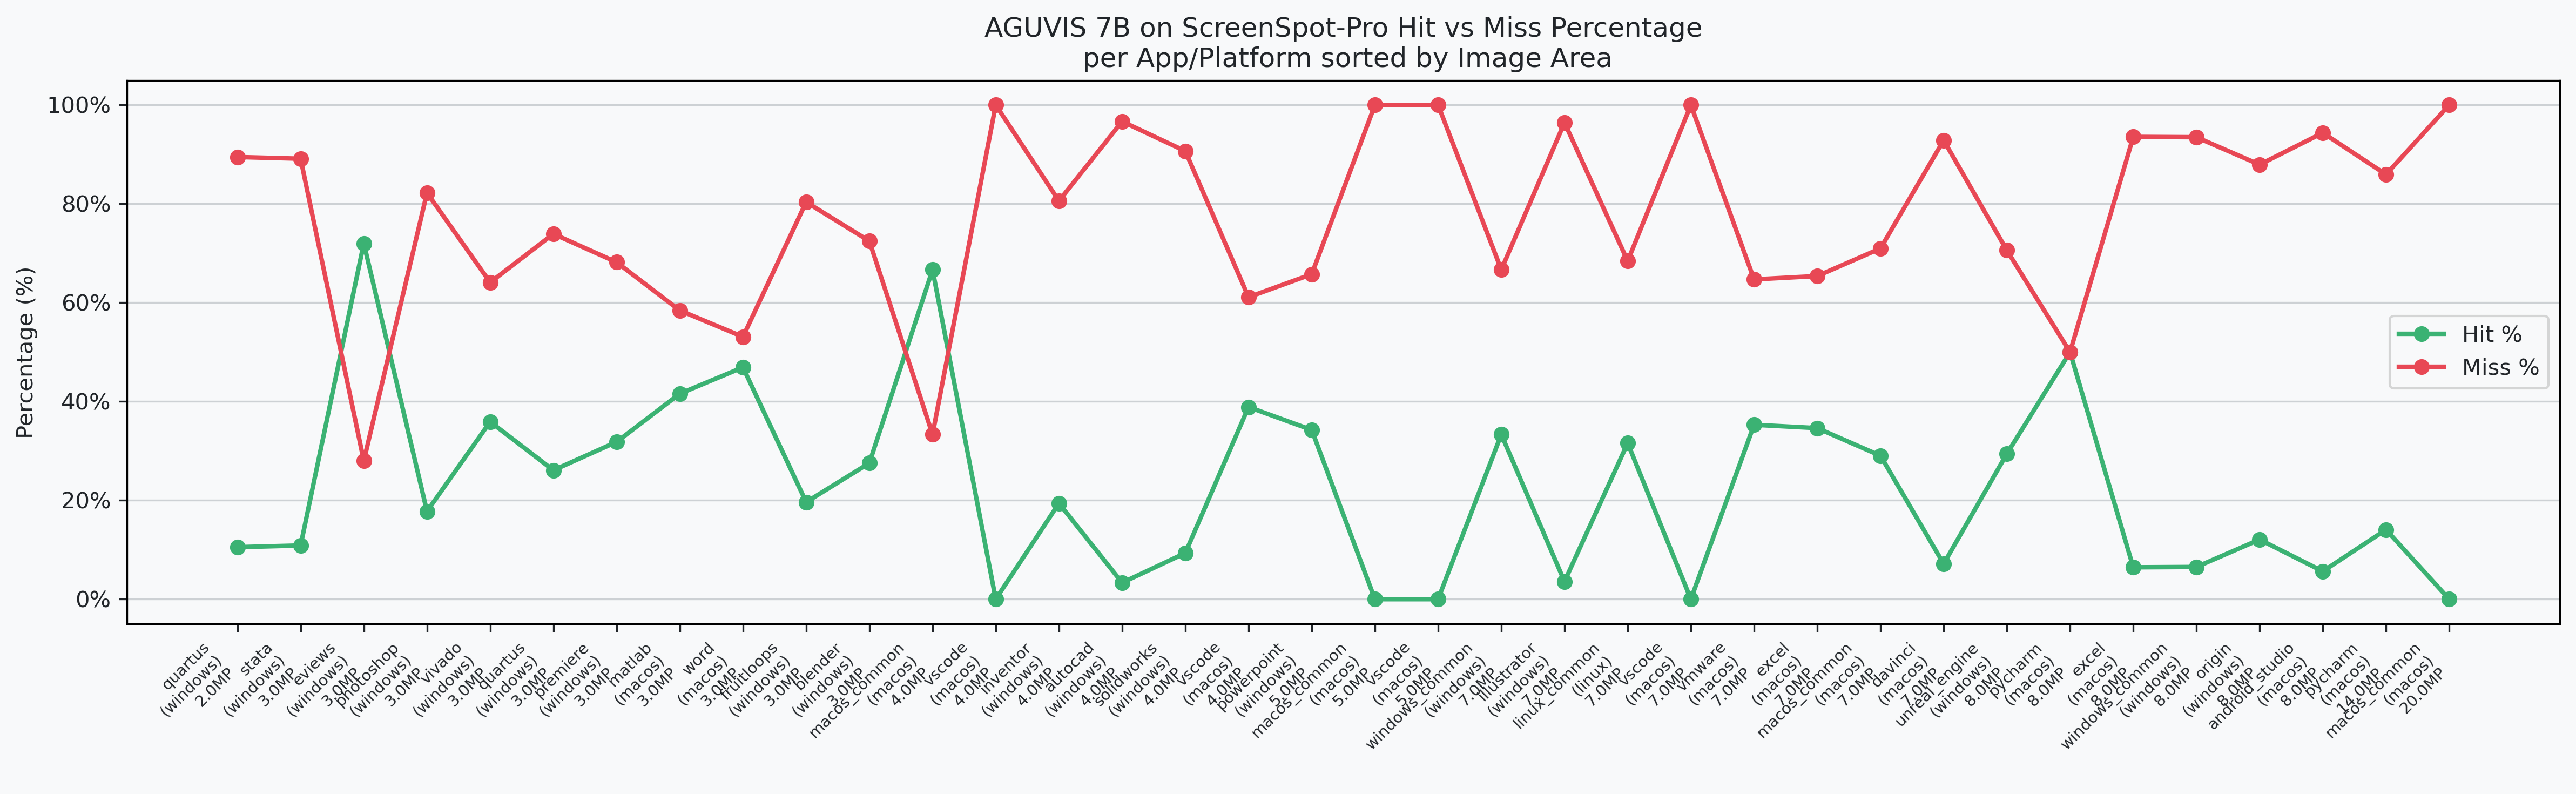

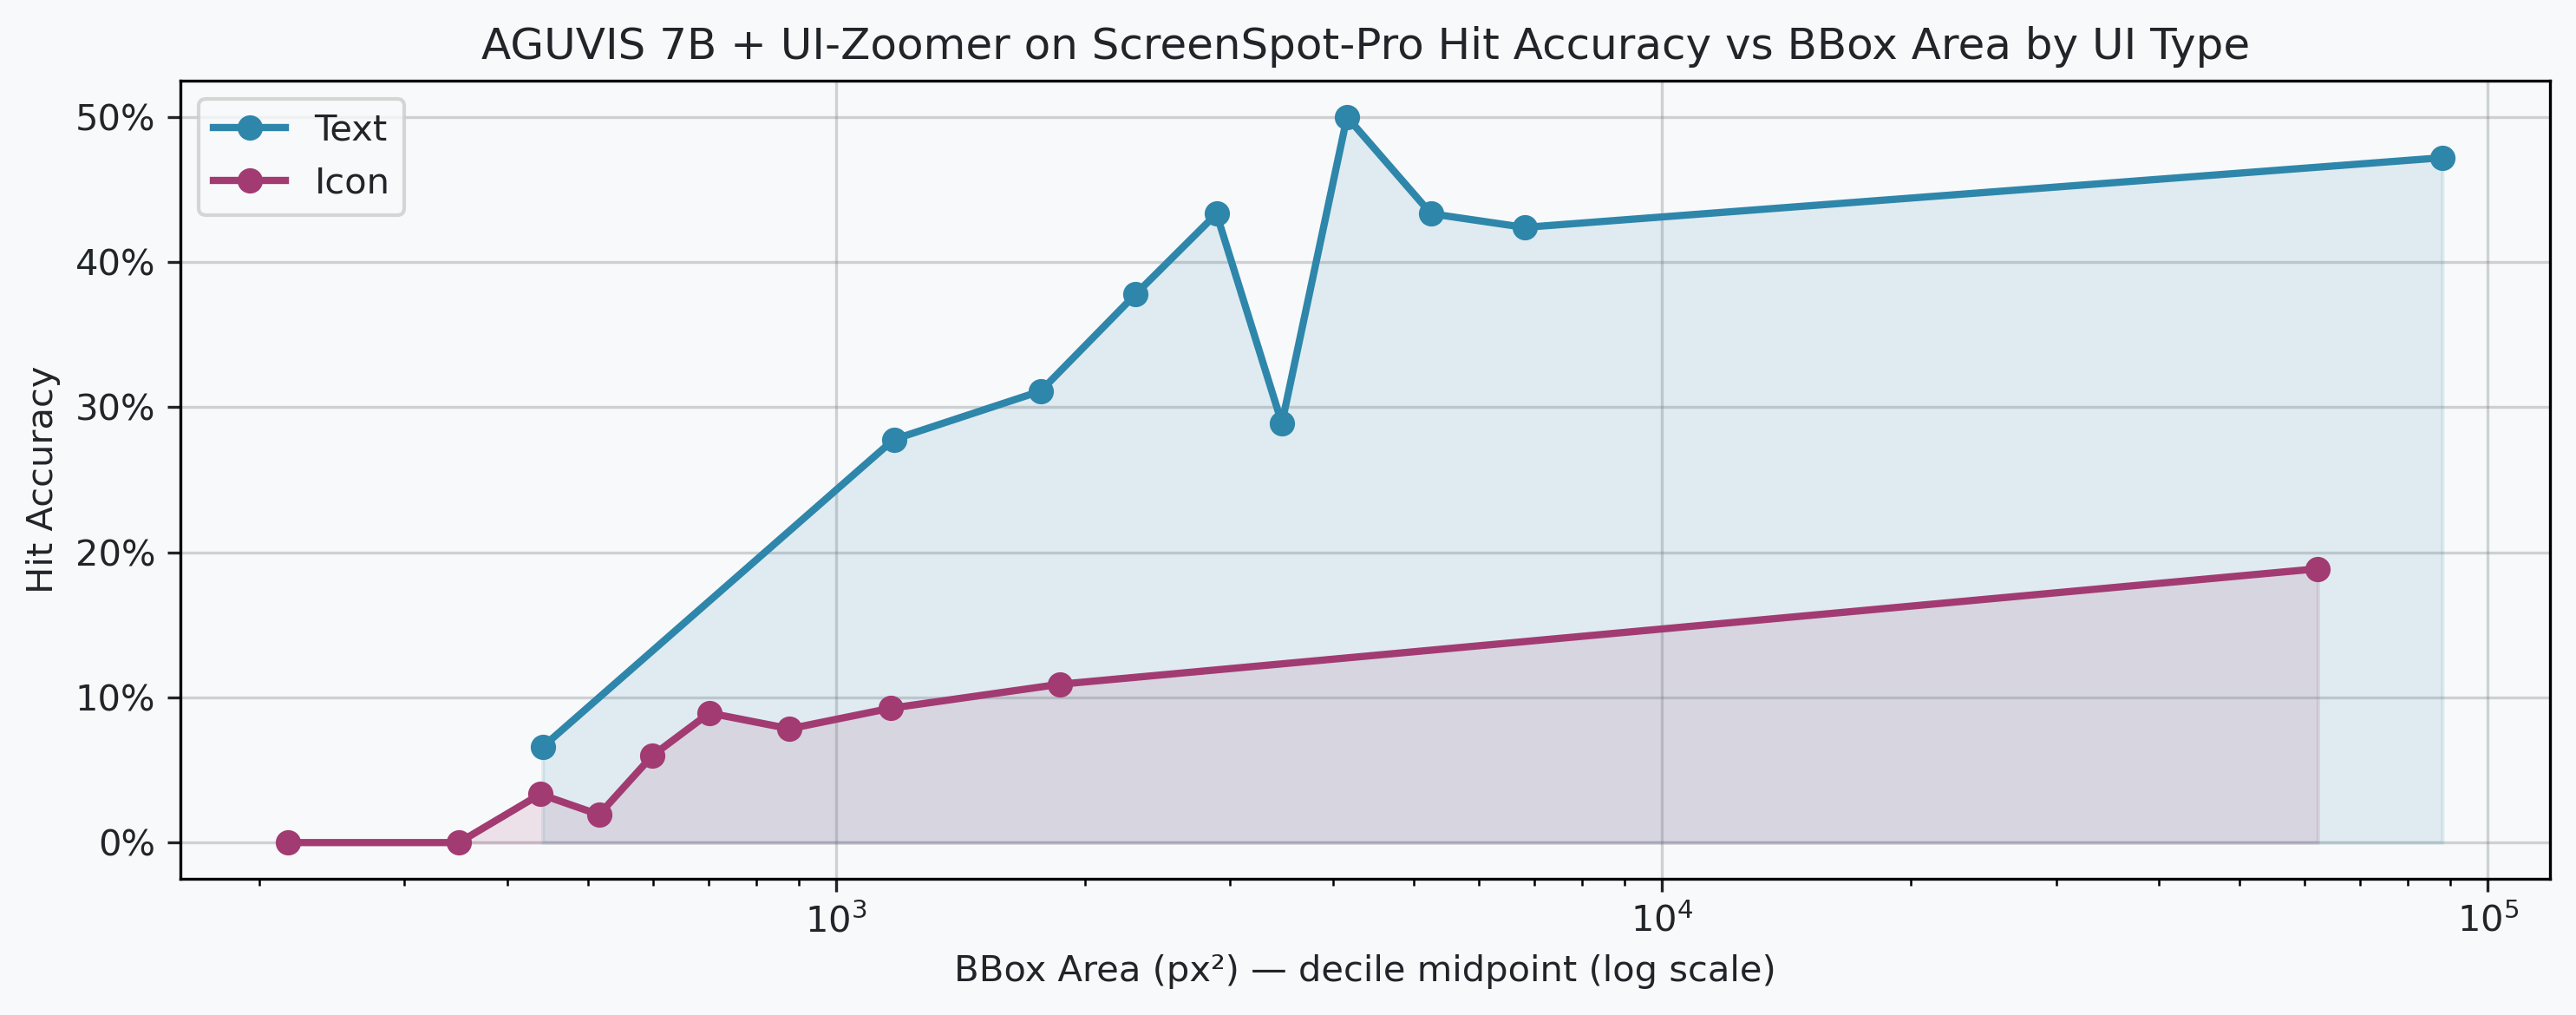

In [28]:
def plot_hit_miss_pct_by_img_area(df):
    # Group and aggregate properly to get raw counts first
    grp = df.groupby(['application', 'platform', 'img_area'])['hit']
    summary = grp.agg(hit='sum', total='count').reset_index()
    summary['miss'] = summary['total'] - summary['hit']
    
    # --- Calculate Percentages ---
    summary['hit_pct'] = (summary['hit'] / summary['total']) * 100
    summary['miss_pct'] = (summary['miss'] / summary['total']) * 100
    
    summary = summary.sort_values('img_area')
    summary['label'] = summary.apply(
        lambda r: f"{r['application']}\n({r['platform']})\n{r['img_area']//1_000_000:.1f}MP", axis=1
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])
    x = range(len(summary))
    
    # --- Plot the percentage columns instead of raw counts ---
    ax.plot(x, summary['hit_pct'],  marker='o', color=C2A_PALETTE["success"], label='Hit %',  linewidth=2)
    ax.plot(x, summary['miss_pct'], marker='o', color=C2A_PALETTE["warning"], label='Miss %', linewidth=2)
    
    ax.set_xticks(list(x))
    ax.set_xticklabels(summary['label'], fontsize=7, color=C2A_PALETTE["text"], rotation=45, ha='right')
    
    # --- Update Labels and Y-axis Formatting ---
    ax.set_ylabel("Percentage (%)", color=C2A_PALETTE["text"])
    ax.set_title("AGUVIS 7B on ScreenSpot-Pro Hit vs Miss Percentage\n per App/Platform sorted by Image Area", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    
    # Set y-axis from 0 to 100 and add % formatting
    ax.set_ylim(-5, 105) # Added slight padding so dots don't clip at exactly 0 or 100
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("./results/aguvis-screenspot-pro-hit-miss-perct-per-app-img-area.png")
    plt.show()

def plot_accuracy_by_bbox_area(df, n_bins=10):
    ui_styles = {
        "text": {"color": C2A_PALETTE["primary"],   "label": "Text"},
        "icon": {"color": C2A_PALETTE["secondary"],  "label": "Icon"},
    }

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    for ui_type, style in ui_styles.items():
        subset = df[df['ui_type'] == ui_type].copy()
        subset['bbox_area_bin'] = pd.qcut(subset['bbox_area'], q=n_bins, duplicates='drop')
        bin_acc = subset.groupby('bbox_area_bin', observed=True)['hit'].mean().reset_index()
        bin_acc['bin_mid'] = bin_acc['bbox_area_bin'].apply(lambda b: int(b.mid))

        ax.plot(
            bin_acc['bin_mid'], bin_acc['hit'],
            marker='o', color=style["color"], linewidth=2, label=style["label"]
        )
        ax.fill_between(bin_acc['bin_mid'], bin_acc['hit'], alpha=0.12, color=style["color"])

    ax.set_xscale('log')
    ax.set_xlabel("BBox Area (px²) — decile midpoint (log scale)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Hit Accuracy", color=C2A_PALETTE["text"])
    ax.set_title("AGUVIS 7B + UI-Zoomer on ScreenSpot-Pro Hit Accuracy vs BBox Area by UI Type", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(color=C2A_PALETTE["neutral"], alpha=0.3)
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/aguvis-screenspot-pro-hit-acc-vs-bbox-area.png")
    plt.show()



plot_hit_miss_pct_by_img_area(results)
plot_accuracy_by_bbox_area(results, 10)

In [29]:
pd.qcut(results['bbox_area'], q=10, duplicates='drop').value_counts().sort_index()

bbox_area
(63.999, 400.0]       145
(400.0, 570.0]        144
(570.0, 825.0]        144
(825.0, 1320.0]       144
(1320.0, 1944.0]      145
(1944.0, 2716.0]      143
(2716.0, 3500.0]      145
(3500.0, 4624.0]      143
(4624.0, 6642.0]      144
(6642.0, 168476.0]    144
Name: count, dtype: int64

### Visualize Distance to BBox

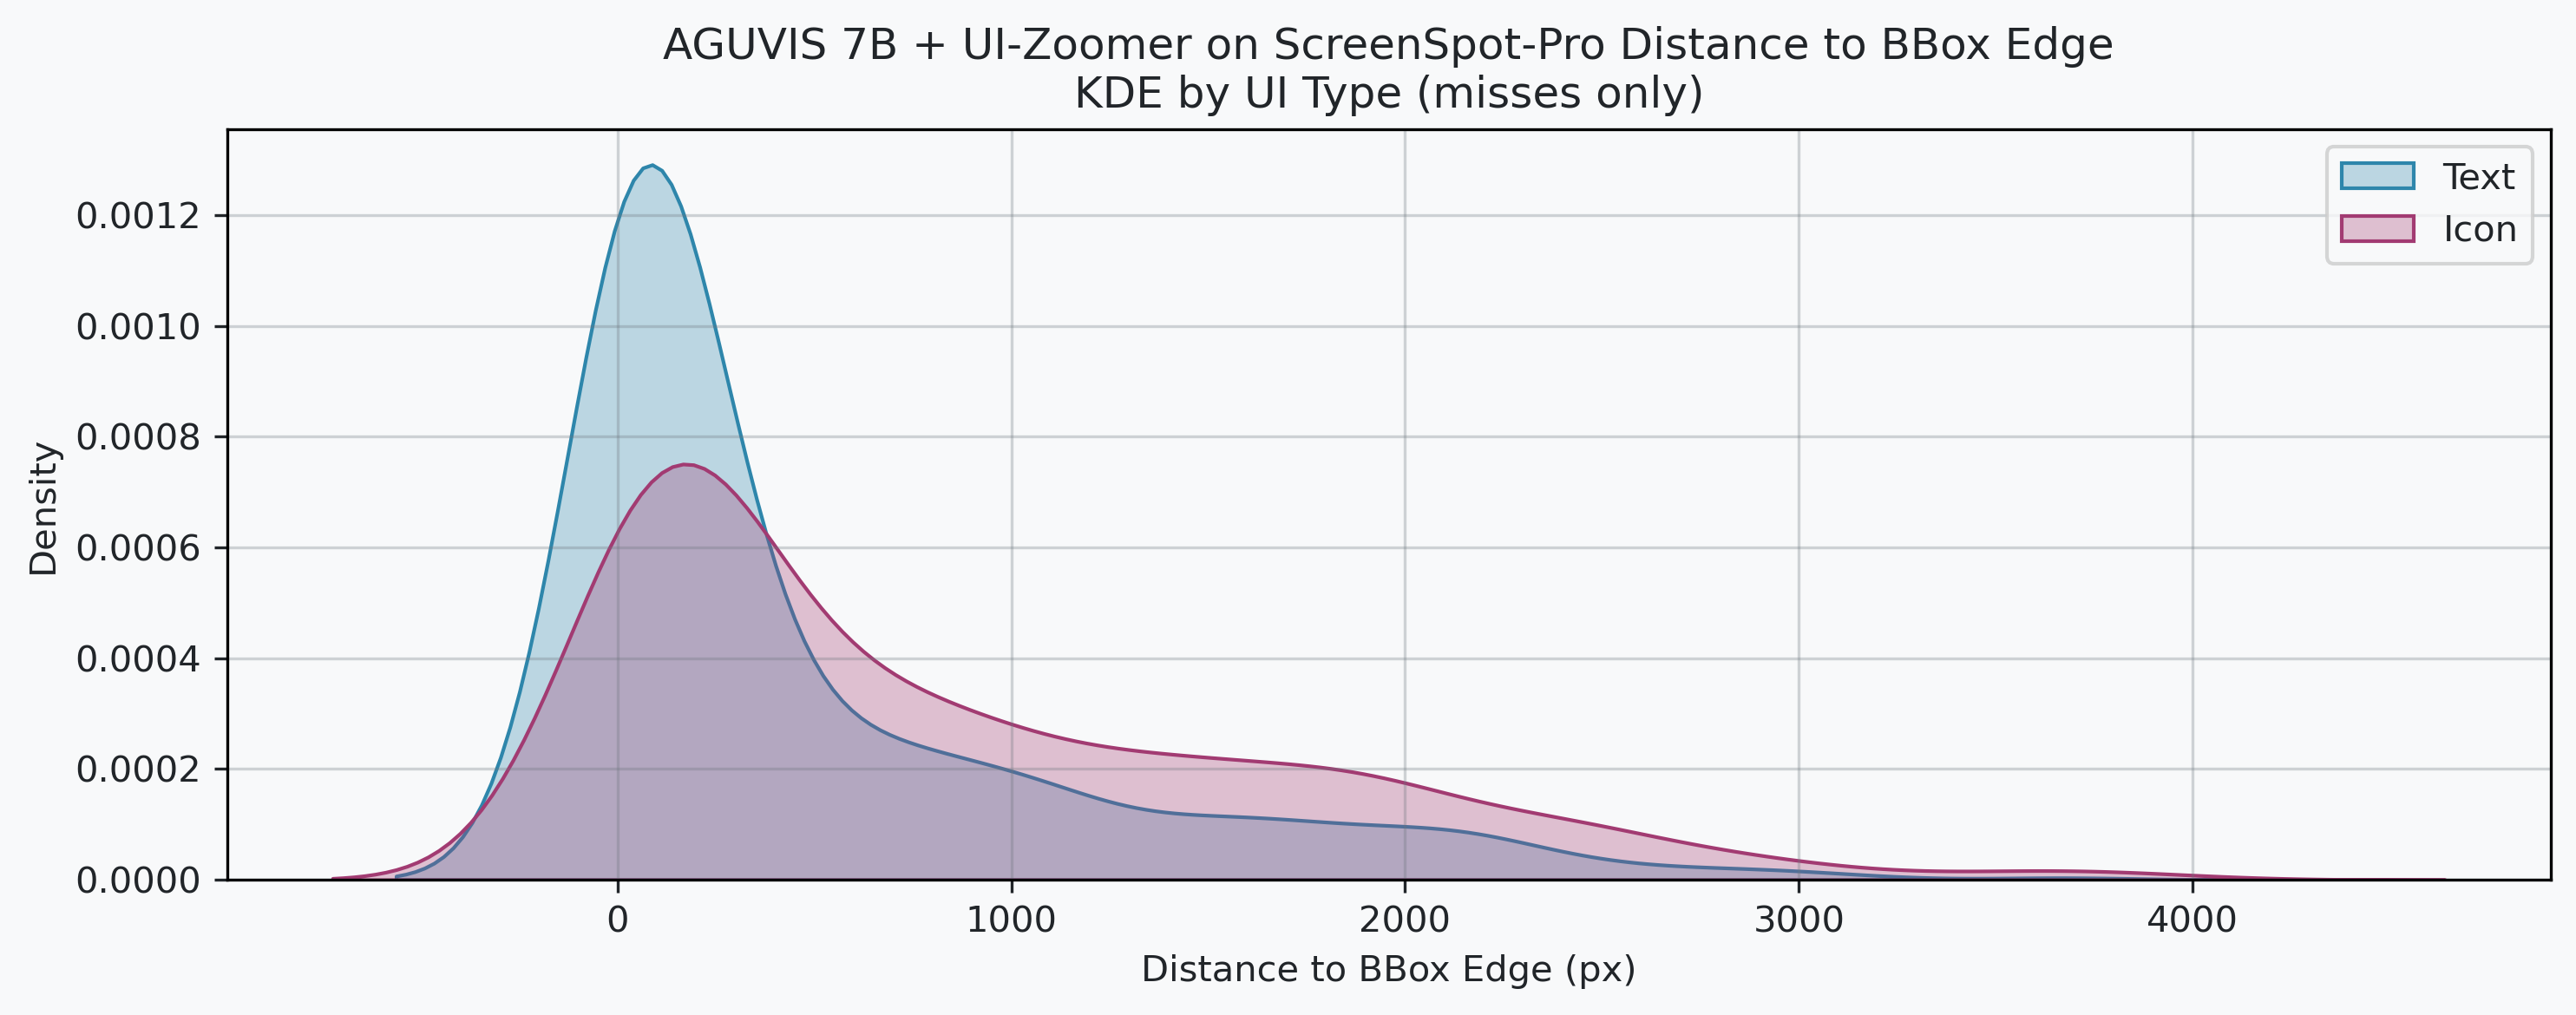

In [30]:
def plot_dist_to_edge_hist(df, figsize=(10, 4)):
    ui_colors = {"text": C2A_PALETTE["primary"], "icon": C2A_PALETTE["secondary"]}
    misses = df[~df['hit']]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    for ui_type, color in ui_colors.items():
        sns.kdeplot(
            misses[misses['ui_type'] == ui_type]['dist_to_edge'],
            ax=ax, color=color, label=ui_type.capitalize(), fill=True, alpha=0.3,
        )

    ax.set_xlabel("Distance to BBox Edge (px)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Density", color=C2A_PALETTE["text"])
    ax.set_title("AGUVIS 7B + UI-Zoomer on ScreenSpot-Pro Distance to BBox Edge\nKDE by UI Type (misses only)", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])
    ax.grid(color=C2A_PALETTE["neutral"], alpha=0.3)

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-to-edge-hist.png")
    plt.show()
    
plot_dist_to_edge_hist(results)

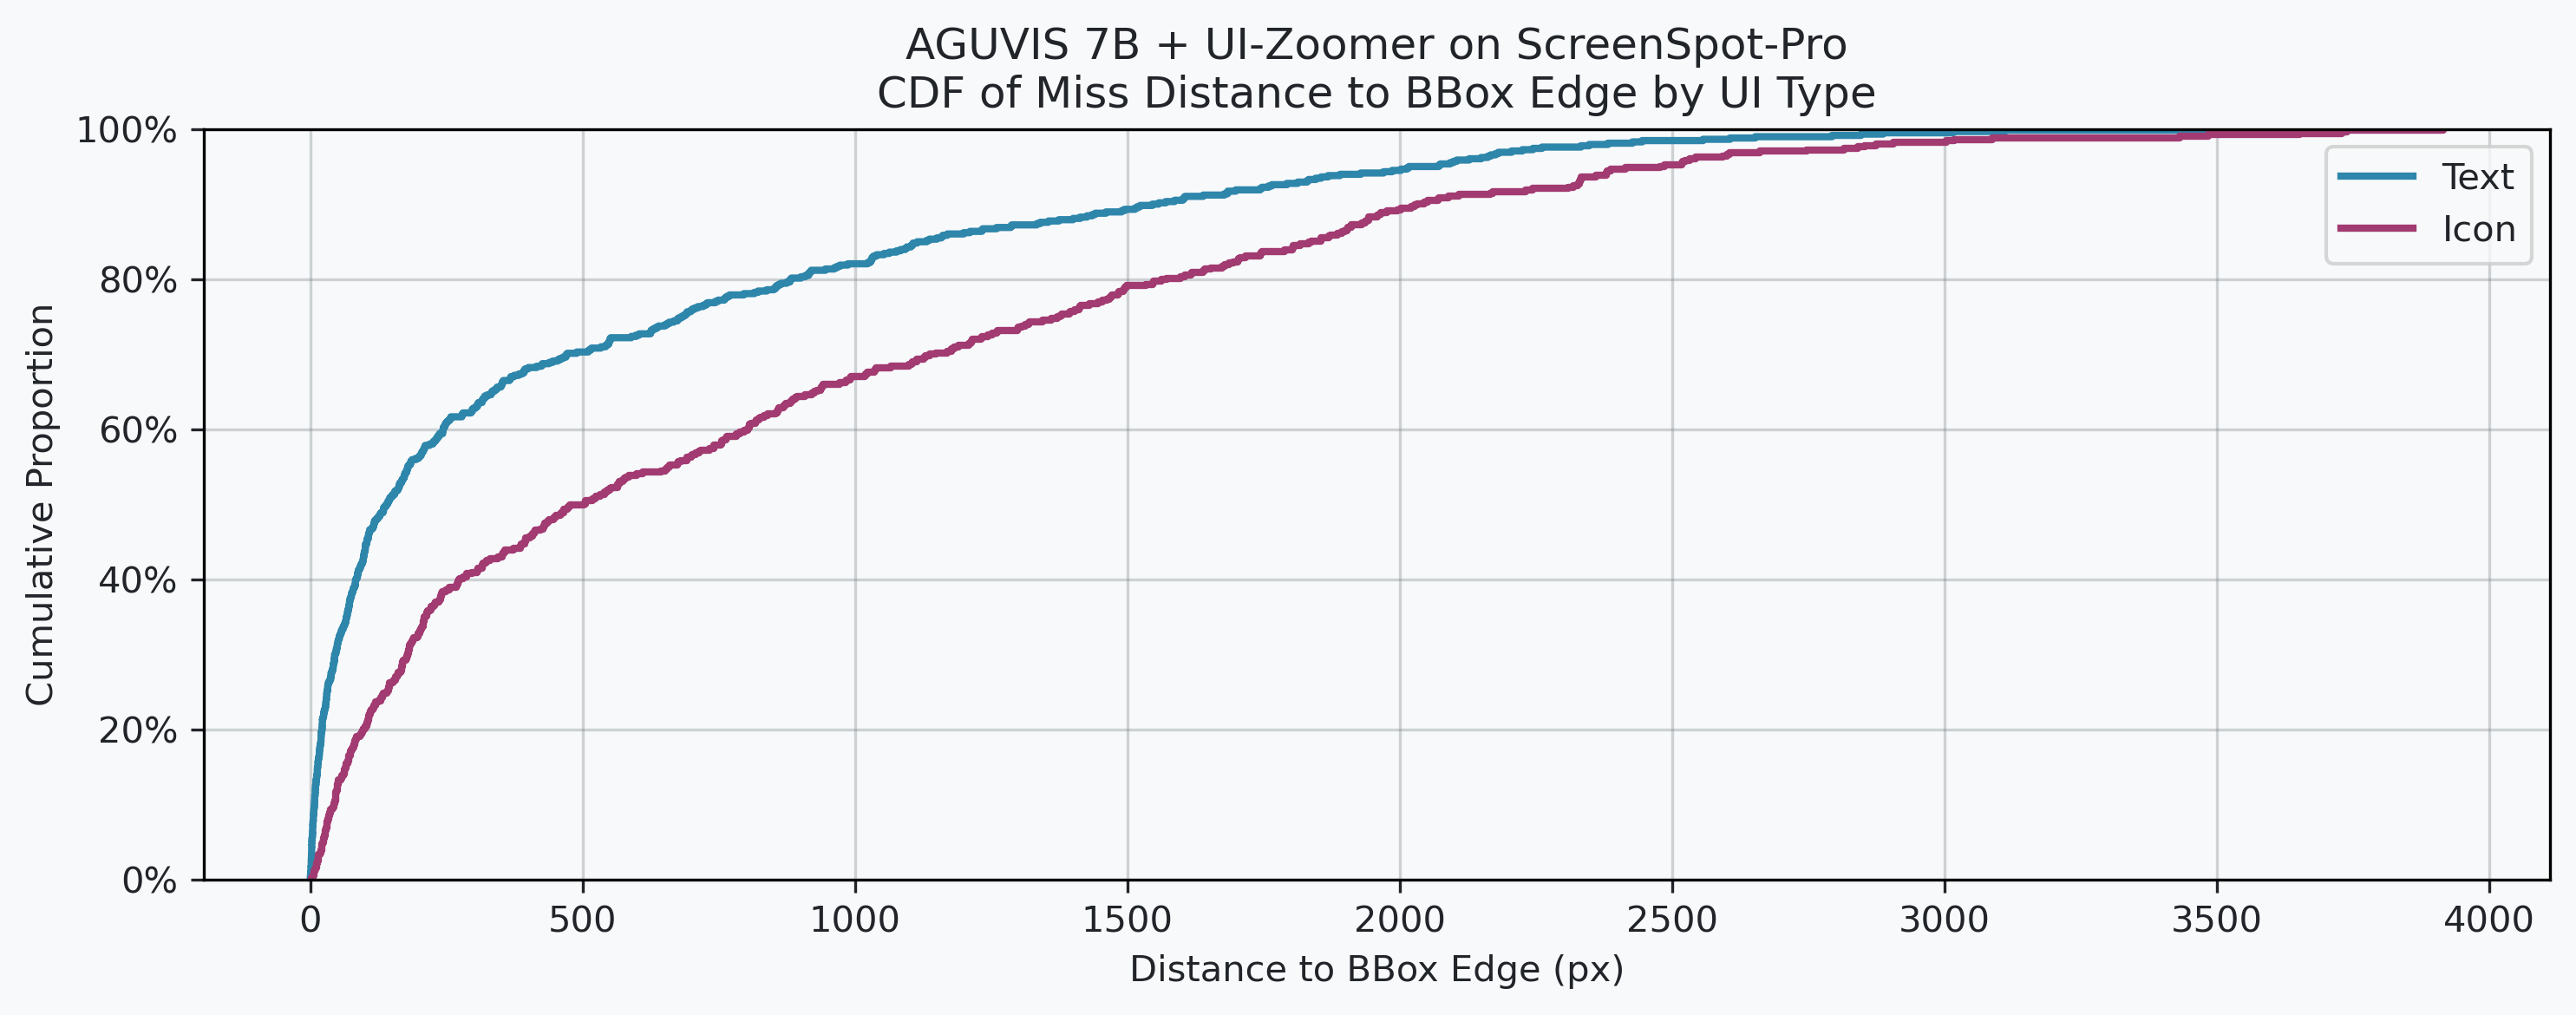

In [31]:
def plot_dist_to_edge_cdf(df, figsize=(10, 4)):
    ui_colors = {"text": C2A_PALETTE["primary"], "icon": C2A_PALETTE["secondary"]}
    misses = df[~df['hit']]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    for ui_type, color in ui_colors.items():
        sns.ecdfplot(
            misses[misses['ui_type'] == ui_type]['dist_to_edge'],
            ax=ax, color=color, label=ui_type.capitalize(), linewidth=2,
        )

    ax.set_xlabel("Distance to BBox Edge (px)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Cumulative Proportion", color=C2A_PALETTE["text"])
    ax.set_title("AGUVIS 7B + UI-Zoomer on ScreenSpot-Pro\nCDF of Miss Distance to BBox Edge by UI Type", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])
    ax.grid(color=C2A_PALETTE["neutral"], alpha=0.3)

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-to-edge-cdf.png")
    plt.show()
    
plot_dist_to_edge_cdf(results)

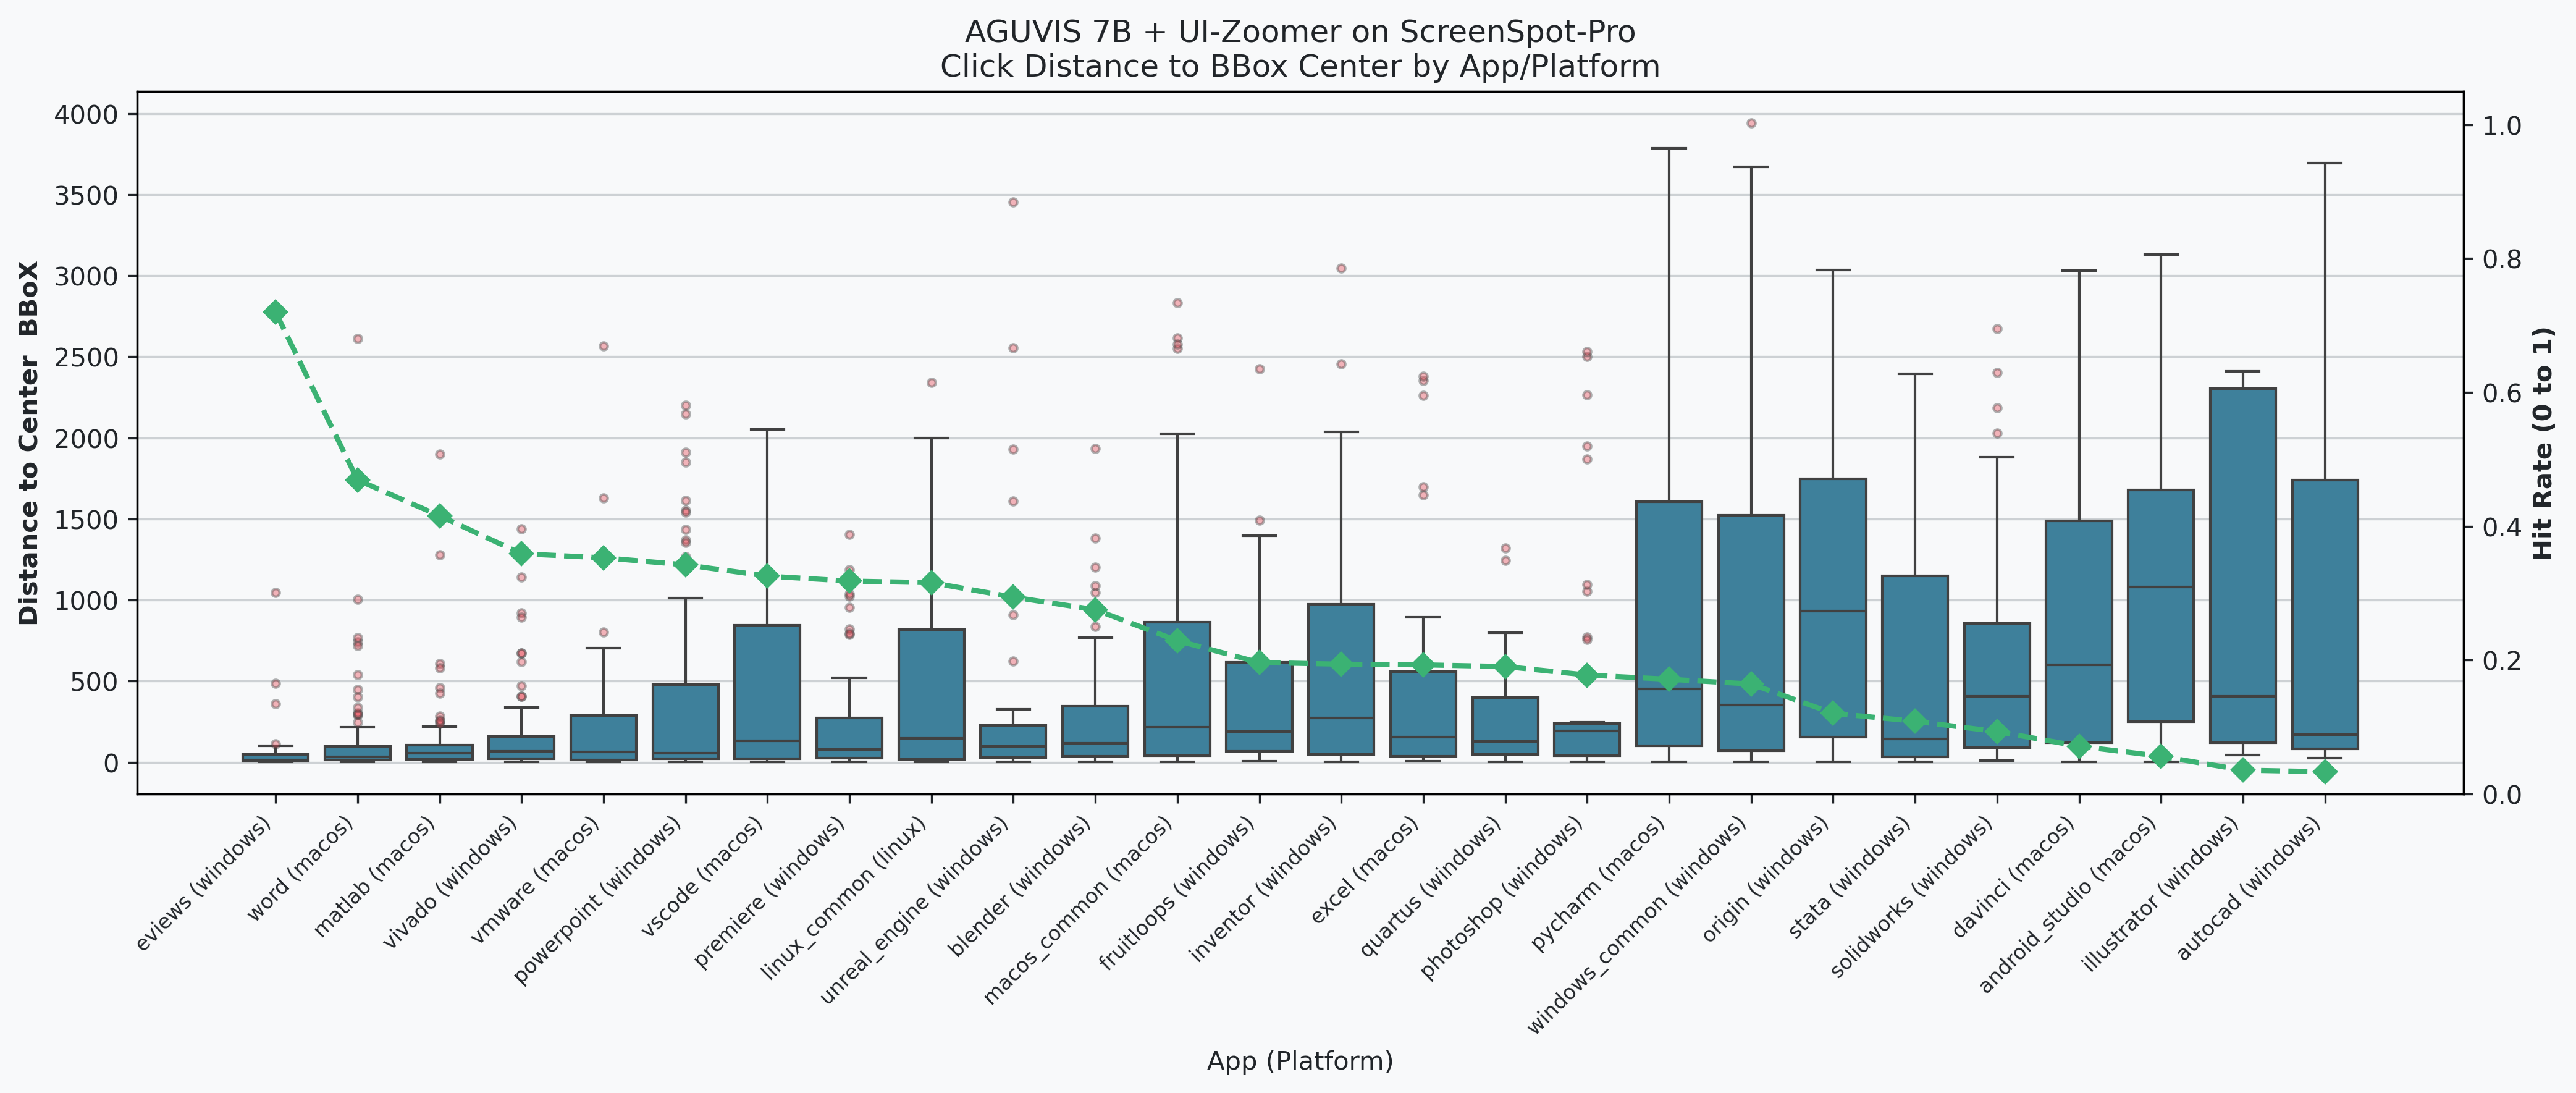

In [32]:
def plot_dist_center_by_app(df, figsize=(14, 6)):
    # 1. Calculate the hit rates and define the order
    hit_stats = df.groupby('app/platform')['hit'].mean().sort_values(ascending=False)
    order = hit_stats.index.tolist()
    hit_rates = hit_stats.values

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    # 2. Draw the original boxplot on the primary (left) Y-axis
    sns.boxplot(
        data=df, x='app/platform', y='dist_to_center', order=order,
        color=C2A_PALETTE["primary"],
        flierprops=dict(marker='o', markerfacecolor=C2A_PALETTE["warning"], markersize=3, alpha=0.4),
        ax=ax,
    )

    ax.set_xlabel("App (Platform)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Distance to Center  BBoX", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_title("AGUVIS 7B + UI-Zoomer on ScreenSpot-Pro\nClick Distance to BBox Center by App/Platform", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', color=C2A_PALETTE["text"], fontsize=8)
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)

    # ==========================================
    # 3. NEW: Add a secondary Y-axis for Hit Rate
    # ==========================================
    ax2 = ax.twinx()  # Create a second axes that shares the same x-axis
    
    # Use your secondary color if it exists, otherwise fallback to red or orange
    line_color = C2A_PALETTE["success"] 
    
    # Plot the line chart
    ax2.plot(
        range(len(order)), hit_rates, 
        color=C2A_PALETTE["success"], marker='D', markersize=6, linewidth=2, linestyle='--'
    )
    
    # Format the secondary axis
    ax2.set_ylabel("Hit Rate (0 to 1)", color=C2A_PALETTE["text"], fontweight='bold')
    ax2.set_ylim(0, 1.05)  # Force axis to go from 0 to slightly above 1 (100%)
    ax2.tick_params(axis='y', colors=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-center-by-app.png")
    plt.show()
    
plot_dist_center_by_app(results)

/tmp/ipykernel_706791/3809957841.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


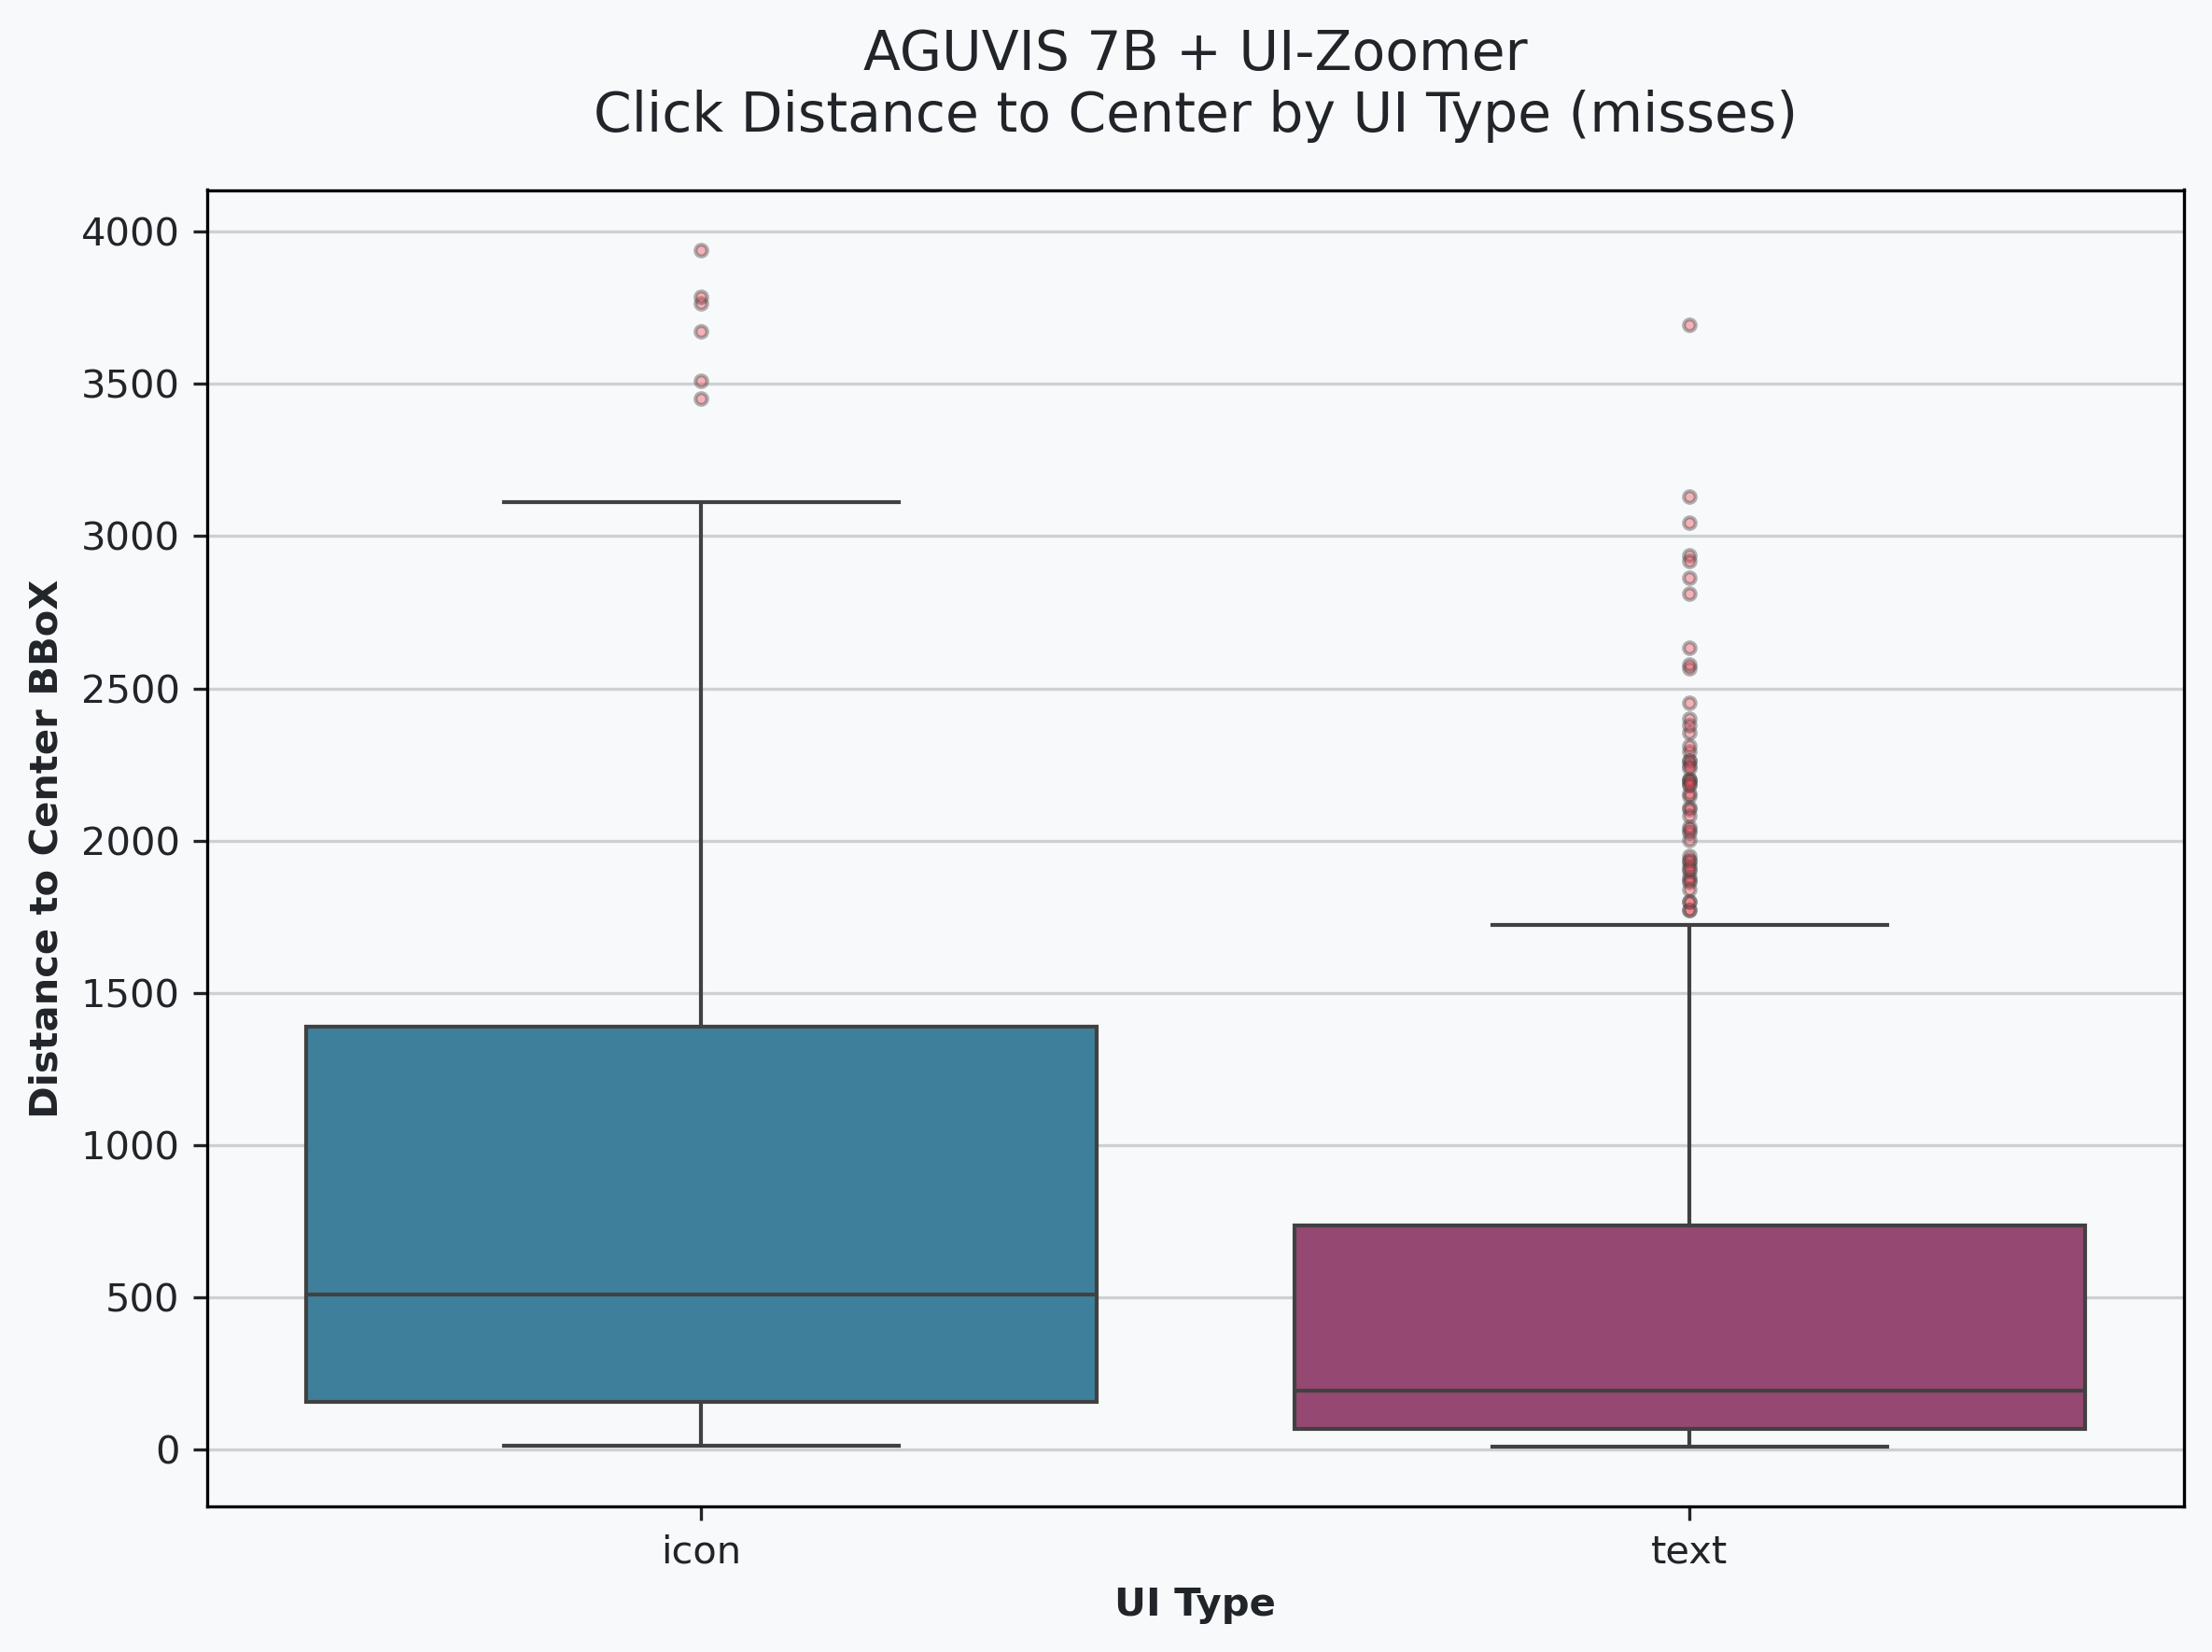

In [33]:
def plot_dist_center_by_ui_type(df, figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    # Apply your custom background colors
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    # Draw the boxplot. 
    # x='ui_type' automatically splits the data into separate boxes for Text and Icon.
    sns.boxplot(
        data=df[~df['hit']], 
        x='ui_type', 
        y='dist_to_center',
        palette=[C2A_PALETTE.get("primary", "#3498db"), C2A_PALETTE.get("secondary", "#9b59b6")],
        flierprops=dict(marker='o', markerfacecolor=C2A_PALETTE["warning"], markersize=3, alpha=0.4),
        ax=ax,
    )

    # Styling the labels and title
    ax.set_xlabel("UI Type", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_ylabel("Distance to Center BBoX", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_title("AGUVIS 7B + UI-Zoomer\nClick Distance to Center by UI Type (misses)", color=C2A_PALETTE["text"], fontsize=14, pad=15)
    
    # Tick marks and grid
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-center-by-ui-type.png")
    plt.show()

# To run it:
plot_dist_center_by_ui_type(results)

/tmp/ipykernel_706791/3848195492.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


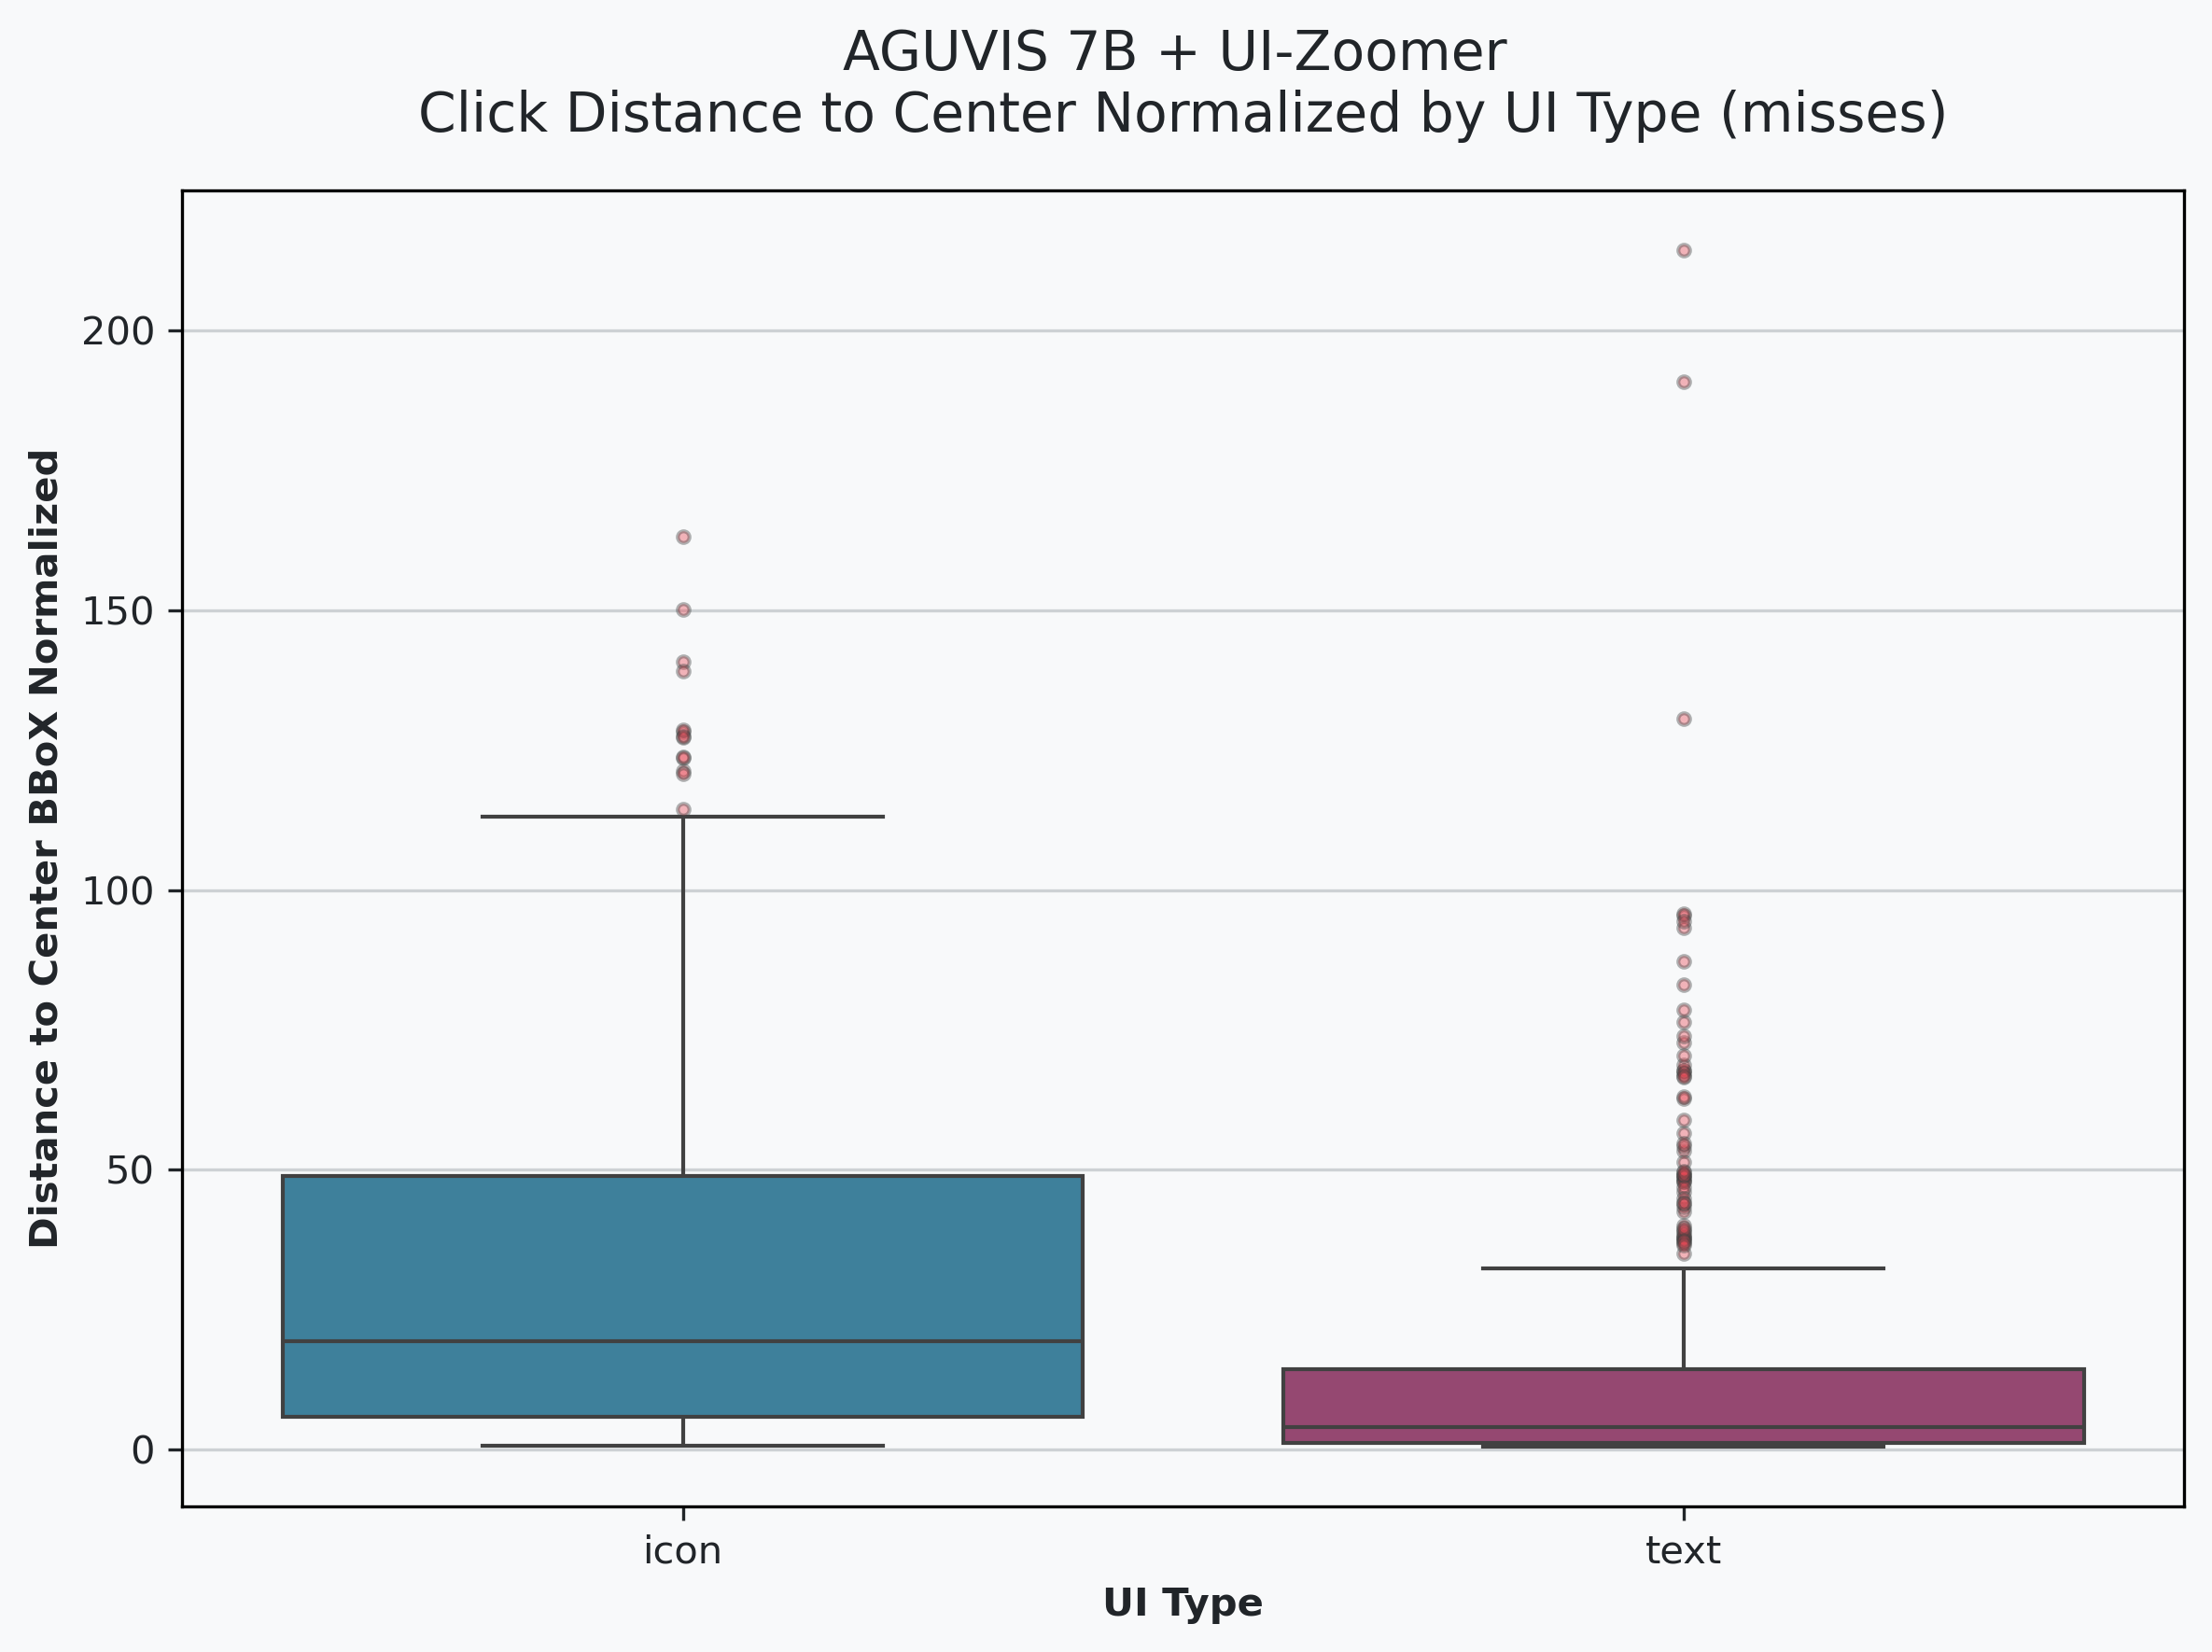

In [34]:
def plot_dist_center_by_ui_type(df, figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    # Apply your custom background colors
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    # Draw the boxplot. 
    # x='ui_type' automatically splits the data into separate boxes for Text and Icon.
    sns.boxplot(
        data=df[~df['hit']], 
        x='ui_type', 
        y='dist_to_center_norm',
        palette=[C2A_PALETTE.get("primary", "#3498db"), C2A_PALETTE.get("secondary", "#9b59b6")],
        flierprops=dict(marker='o', markerfacecolor=C2A_PALETTE["warning"], markersize=3, alpha=0.4),
        ax=ax,
    )

    # Styling the labels and title
    ax.set_xlabel("UI Type", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_ylabel("Distance to Center BBoX Normalized", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_title("AGUVIS 7B + UI-Zoomer \nClick Distance to Center Normalized by UI Type (misses)", color=C2A_PALETTE["text"], fontsize=14, pad=15)
    
    # Tick marks and grid
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-center-norm-by-ui-type.png")
    plt.show()

# To run it:
plot_dist_center_by_ui_type(results)